In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import yfinance as yf
from datetime import time
sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

# Para ir tocando data_cleaner sin tener que reiniciar el kernel
%load_ext autoreload
%autoreload 2

In [2]:
# Configuración para datos a 5m
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
   
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw)

df

,symbol,datetime,open,high,low,close,volume,trade_count,vwap,volume_norm,...,log_ret_ch,log_ret_cl,log_ret_vwap,log_return_lag1,log_return_lag3,log_return_lag5,vol_rolling,rsi,macd,macd_signal
0,QQQ,2022-01-03 10:40:00+00:00,400.0700,400.08,400.03,400.0300,928.0,26.0,400.053334,-1.038042,...,-0.000125,0.000000,-0.000083,0.000275,0.000200,-0.000100,0.000261,77.599999,0.000423,0.000313
1,QQQ,2022-01-03 10:45:00+00:00,400.0200,400.07,400.00,400.0700,1083.0,38.0,400.032727,-0.923369,...,0.000000,0.000175,-0.000052,-0.000200,-0.000200,0.000300,0.000260,76.666666,0.000430,0.000336
2,QQQ,2022-01-03 10:50:00+00:00,400.0100,400.07,399.96,400.0500,4364.0,43.0,400.017493,-0.269167,...,-0.000050,0.000225,-0.000038,0.000100,0.000275,0.000200,0.000255,75.206611,0.000427,0.000354
3,QQQ,2022-01-03 10:55:00+00:00,400.0700,400.07,400.07,400.0700,208.0,5.0,400.070000,-0.973547,...,0.000000,0.000000,0.000131,-0.000050,-0.000200,-0.000200,0.000225,73.451327,0.000424,0.000368
4,QQQ,2022-01-03 11:00:00+00:00,400.1500,400.40,400.15,400.3500,5741.0,83.0,400.314086,0.077401,...,-0.000125,0.000500,0.000610,0.000050,0.000100,0.000275,0.000257,77.272726,0.000472,0.000389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189326,QQQ,2026-01-01 00:35:00+00:00,614.2984,614.32,614.24,614.2639,635.0,48.0,614.287381,-0.986389,...,-0.000091,0.000039,0.000025,0.000016,-0.000080,0.000016,0.000053,41.026336,-0.000044,-0.000070
189327,QQQ,2026-01-01 00:40:00+00:00,614.3000,614.30,614.30,614.3000,129.0,12.0,614.300000,-1.211694,...,0.000000,0.000000,0.000021,-0.000059,-0.000018,0.000065,0.000053,48.699270,-0.000040,-0.000064
189328,QQQ,2026-01-01 00:45:00+00:00,614.2800,614.32,614.28,614.3085,991.0,48.0,614.301639,-0.593634,...,-0.000019,0.000046,0.000003,0.000059,0.000016,-0.000080,0.000053,49.948952,-0.000036,-0.000058
189329,QQQ,2026-01-01 00:50:00+00:00,614.2903,614.30,614.23,614.2400,4718.0,128.0,614.258774,1.783280,...,-0.000098,0.000016,-0.000070,0.000014,-0.000059,-0.000018,0.000059,42.378047,-0.000040,-0.000055


In [3]:
df.columns

Index(['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume',
       'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return',
       'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl',
       'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1',
       'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd',
       'macd_signal'],
      dtype='object')

In [4]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# --- Ajusta paths por si estás en notebook ---
ROOT = Path(".").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Import robusto (según tengas el proyecto)
try:
    from GARCH import Garch11OOSBest
except Exception:
    from src.GARCH import Garch11OOSBest

# 1) Instanciar con los mismos params que tu script
m = Garch11OOSBest(
    source="alpaca",
    symbol="QQQ",
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
    horizonte_horas=2,
    test_ratio=0.2,
    train_val_ratio=0.2,
    escala_returns=100.0,
    usar_horario_regular=True,
    usar_estacionalidad=True,
    season_smooth_half_window=5,
    fit_window_train_bars=16000,
    mean_mode="Zero",
    dist_mode="normal",
)

# 2) Pipeline interno (tal cual tu main)
m.cargar()
m.crear_target()
m.split()
m.ajustar_estacionalidad_train()
m.fit_train_fit()
m.filtrar_h_all()

# 3) Calcular sigma_2h para TODO el dataset (donde haya futuro suficiente)
df_g = m.df[["datetime"]].copy()
sig = np.full(len(df_g), np.nan, dtype=float)

# Nota: predecir_vol_futura_en_t devuelve None al final si no hay futuro.
for t in range(len(df_g)):
    out = m.predecir_vol_futura_en_t(t=t, devolver_path=False)
    if out is not None:
        sig[t] = out["sigma_2h"]

df_g["garch_vol_2h"] = sig
df_g = df_g.dropna(subset=["garch_vol_2h"]).reset_index(drop=True)

# 4) Guardar para reusar (evitas recomputar GARCH cada vez)
out_path = "garch_vol_2h_by_datetime.csv"
df_g.to_csv(out_path, index=False)

print("Saved:", out_path, "| rows:", len(df_g))
print("garch_vol_2h quantiles:", np.quantile(df_g["garch_vol_2h"].values, [0.01,0.05,0.1,0.5,0.9,0.95,0.99]))
print("head:\n", df_g.head(3).to_string(index=False))


>>> EJECUTANDO: GARCH(1,1) OOS BEST (H=2H) <<<
convergence_flag: 0
opt_message: Optimization terminated successfully

=== Params GARCH(1,1) (TRAIN_FIT) ===
omega=448.085739 alpha=0.100947 beta=0.875036 alpha+beta=0.975983 mu=0.000000
Saved: garch_vol_2h_by_datetime.csv | rows: 79167
garch_vol_2h quantiles: [0.00059981 0.00064707 0.00068026 0.00092084 0.00155706 0.00186155
 0.0027477 ]
head:
                  datetime  garch_vol_2h
2022-01-03 14:30:00+00:00      0.001302
2022-01-03 14:35:00+00:00      0.001278
2022-01-03 14:40:00+00:00      0.001240


In [5]:
import numpy as np
import pandas as pd

HORIZON = 24  # 24 velas de 5m = 2 horas

# ratios (usa los mismos que tu pipeline)
TEST_RATIO = 0.20
VAL_RATIO  = 0.20  # dentro del tramo train (para calibrar umbrales en train_only)

# hiperparámetros del target
VOL_LOW_Q = 0.30   # "poca vol" = p30 de TRAIN
K_SIGMA   = 0.60   # umbral de retorno en "sigmas" de GARCH

df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# -------------------------
# 1) MERGE GARCH vol 2h
# -------------------------
df_g = pd.read_csv("garch_vol_2h_by_datetime.csv")
df_g["datetime"] = pd.to_datetime(df_g["datetime"], utc=True, errors="coerce")
df_g = df_g.dropna(subset=["datetime"]).sort_values("datetime")

df = df.merge(df_g[["datetime", "garch_vol_2h"]], on="datetime", how="left")
df = df.dropna(subset=["garch_vol_2h"]).reset_index(drop=True)

# -------------------------
# 2) TARGET (sin cruzar día NY)
# -------------------------
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

df["fwd_logret_2h"] = np.log(df["close_future"] / df["close"])

# -------------------------
# 3) Umbrales SOLO con TRAIN
# -------------------------
n = len(df)
corte_test = int(n * (1 - TEST_RATIO))
corte_val  = int(corte_test * (1 - VAL_RATIO))
df_train_only = df.iloc[:corte_val].copy()

vol_low = float(df_train_only["garch_vol_2h"].quantile(VOL_LOW_Q))
thr_dyn = K_SIGMA * df["garch_vol_2h"].values

# clases: 0=DOWN, 1=FLAT, 2=UP
df["direction_2h"] = 1  # por defecto FLAT

# si vol baja => FLAT (lateral)
low_vol_mask = (df["garch_vol_2h"].values <= vol_low)

# si no vol baja, decide por umbral dinamico
hi_vol_mask = ~low_vol_mask
df.loc[hi_vol_mask & (df["fwd_logret_2h"].values >  thr_dyn), "direction_2h"] = 2
df.loc[hi_vol_mask & (df["fwd_logret_2h"].values < -thr_dyn), "direction_2h"] = 0
df["direction_2h"] = df["direction_2h"].astype(np.int8)

# Limpieza auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

print("vol_low (train p30) =", vol_low)
print("Frac low_vol =", float(low_vol_mask.mean()))
print("Class dist:", df["direction_2h"].value_counts(normalize=True).sort_index().to_dict())
print("Rows df:", len(df))


vol_low (train p30) = 0.00082625699907681
Frac low_vol = 0.3538978128686814
Class dist: {0: 0.2729285779108812, 1: 0.42261548234867047, 2: 0.3044559397404483}
Rows df: 55095


In [6]:
import numpy as np
import pandas as pd

DOWN, FLAT, UP = 0, 1, 2

TEST_RATIO = 0.20
VAL_RATIO  = 0.20

n = len(df)
corte_test = int(n * (1 - TEST_RATIO))
corte_val  = int(corte_test * (1 - VAL_RATIO))
df_train_only = df.iloc[:corte_val].copy()

qs = [0.20, 0.25, 0.30, 0.35]
ks = [0.50, 0.60, 0.70, 0.80]

rows = []
vol = df["garch_vol_2h"].values
ret = df["fwd_logret_2h"].values

for q in qs:
    vol_low = float(df_train_only["garch_vol_2h"].quantile(q))
    low_vol_mask = (vol <= vol_low)

    for k in ks:
        thr = k * vol
        y = np.full(len(df), FLAT, dtype=np.int8)

        hi = ~low_vol_mask
        y[hi & (ret >  thr)] = UP
        y[hi & (ret < -thr)] = DOWN

        # dist global (rápido)
        p0 = float(np.mean(y == DOWN))
        p1 = float(np.mean(y == FLAT))
        p2 = float(np.mean(y == UP))
        nonflat = 1.0 - p1

        rows.append((q, k, vol_low, float(low_vol_mask.mean()), p0, p1, p2, nonflat))

res = pd.DataFrame(rows, columns=[
    "VOL_LOW_Q","K_SIGMA","vol_low","frac_low_vol","p_down","p_flat","p_up","nonflat"
])

# Filtro “razonable”: FLAT entre 0.33 y 0.48 y noflat >= 0.45 y clases laterales no ridículas
good = res[(res["p_flat"].between(0.33, 0.48)) & (res["nonflat"] >= 0.45)]
good = good.sort_values(["nonflat","p_flat"], ascending=[False, True])

print("TOP combos:")
print(good.head(12).to_string(index=False))

print("\nAll combos (si quieres verlos):")
print(res.sort_values(["p_flat"], ascending=True).to_string(index=False))


TOP combos:
 VOL_LOW_Q  K_SIGMA  vol_low  frac_low_vol   p_down   p_flat     p_up  nonflat
      0.20      0.6 0.000765      0.253707 0.312206 0.334350 0.353444 0.665650
      0.20      0.7 0.000765      0.253707 0.306253 0.347164 0.346583 0.652836
      0.20      0.8 0.000765      0.253707 0.300009 0.360051 0.339940 0.639949
      0.25      0.5 0.000795      0.303839 0.298902 0.366422 0.334676 0.633578
      0.25      0.6 0.000795      0.303839 0.292749 0.378655 0.328596 0.621345
      0.25      0.7 0.000795      0.303839 0.287195 0.390471 0.322334 0.609529
      0.25      0.8 0.000795      0.303839 0.281350 0.402378 0.316272 0.597622
      0.30      0.5 0.000826      0.353898 0.278646 0.411308 0.310046 0.588692
      0.30      0.6 0.000826      0.353898 0.272929 0.422615 0.304456 0.577385
      0.30      0.7 0.000826      0.353898 0.267919 0.433488 0.298593 0.566512
      0.30      0.8 0.000826      0.353898 0.262492 0.444360 0.293148 0.555640
      0.35      0.5 0.000857      0.4033

In [7]:
HORIZON = 24  # 24 velas de 5m = 2 horas
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# TARGET

## Aseguramos el horario de Nueva York
df["date_ny"] = df["datetime"].dt.tz_convert("America/New_York").dt.date

# el close future no es mas que el precio futuro que se quiere predecir (Esta vez de  la columna date_ny, que indica el del horario de nueva york)
df["close_future"] = df.groupby("date_ny")["close"].shift(-HORIZON)

# elimina las ultimas filas ya que no tenemos datos de ses futuro
df = df.dropna(subset=["close_future"]).reset_index(drop=True)

# la variable direccion compara el precio futuro con el actual, si es mayor guarda 1, y si es menor o igual 0
thr = 0.0005
df["fwd_logret_2h"] = np.log(df["close_future"] / df["close"])

df["direction_2h"] = 1
df.loc[df["fwd_logret_2h"] >  thr, "direction_2h"] = 2
df.loc[df["fwd_logret_2h"] < -thr, "direction_2h"] = 0
df["direction_2h"] = df["direction_2h"].astype(np.int8)

FEATURE_COLUMNS = [
    "log_ret_hl",
    "vwap",
    "volume",
    "garch_vol_2h",
    "rsi",
    "macd",
    "volume_norm"
]

# trade count no es otra cosa que el numero de operaciones que se realizan en el periodo de tiempo de una vela
# trade_count: usa norm si existe, si no raw (y si no existe, no pasa nada)
if "trade_count_norm" in df.columns:
    FEATURE_COLUMNS.append("trade_count_norm")
elif "trade_count" in df.columns:
    FEATURE_COLUMNS.append("trade_count")



# quitar las que no existan (por si Alpaca/YF no trae alguna)
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in df.columns]

# Limpieza de columnas auxiliares
df = df.drop(columns=[c for c in ["close_future", "date_ny"] if c in df.columns])

print("N features:", len(FEATURE_COLUMNS))
print("FEATURE_COLUMNS:", FEATURE_COLUMNS)
print("Rows df:", len(df))

print("direction_2h" in df.columns)
print(df[["close", "direction_2h"]].head())
 

N features: 8
FEATURE_COLUMNS: ['log_ret_hl', 'vwap', 'volume', 'garch_vol_2h', 'rsi', 'macd', 'volume_norm', 'trade_count_norm']
Rows df: 31040
True
      close  direction_2h
0  400.4200             0
1  401.0600             0
2  400.5600             0
3  398.2175             2
4  397.3500             2


True
Columnas numéricas:
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'garch_vol_2h', 'fwd_logret_2h', 'direction_2h']


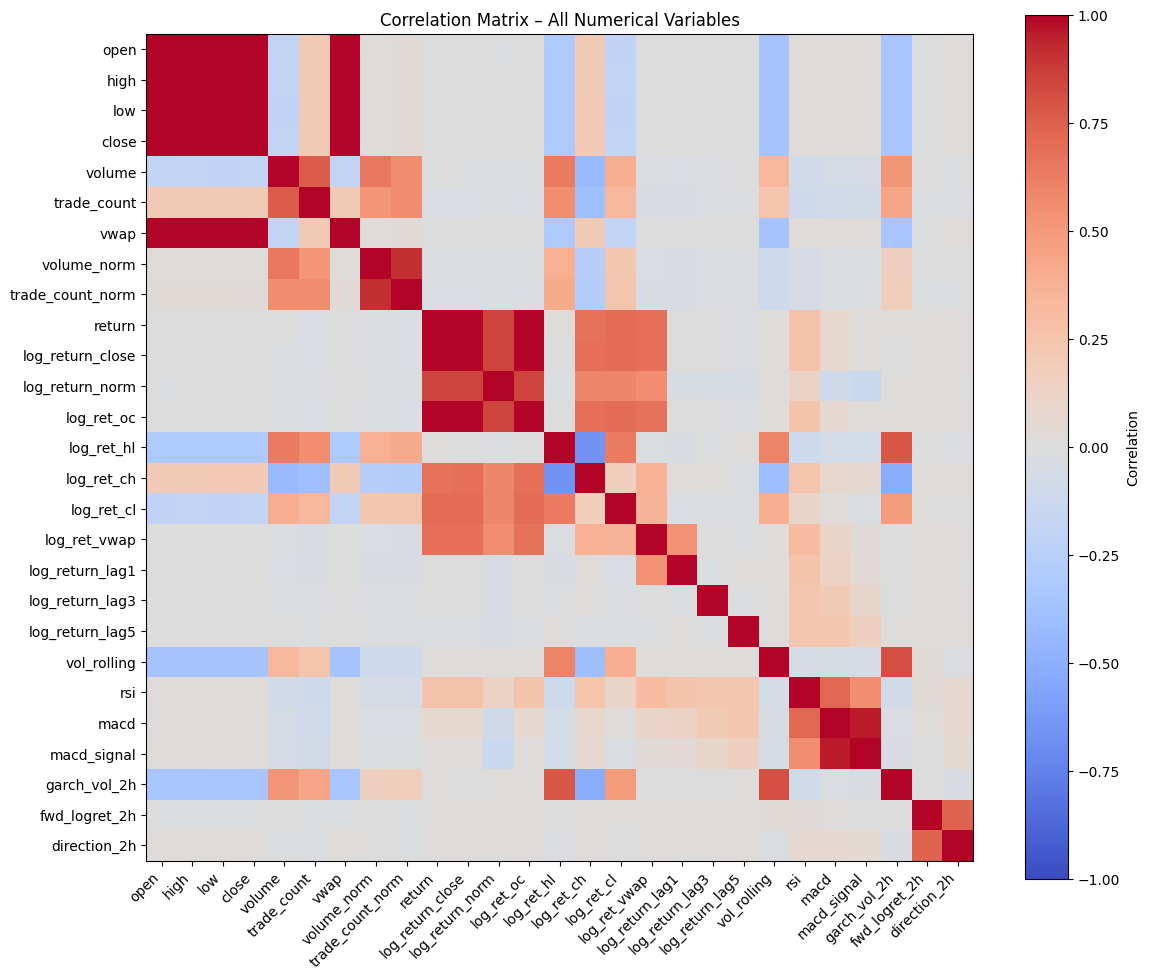

In [8]:
# Columnas numéricas del dataframe

num_cols = df.select_dtypes(include=["int64","int32","float64","float32","int8","int16","float16"]).columns.tolist()
print("direction_2h" in num_cols)


print("Columnas numéricas:")
print(num_cols)

corr_all = df[num_cols].corr()
corr_all["direction_2h"].sort_values(ascending=False)


corr_all = df[num_cols].corr()

corr_all

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))
plt.imshow(corr_all, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_all.columns)), corr_all.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_all.index)), corr_all.index)

plt.title("Correlation Matrix – All Numerical Variables")
plt.tight_layout()
plt.show()



### Sanity Check: Correlación de las variable con la variable target

In [9]:
corr_target = corr_all["direction_2h"].sort_values(ascending=False)
print(corr_target)


direction_2h        1.000000
fwd_logret_2h       0.734261
macd                0.057164
rsi                 0.056147
macd_signal         0.052994
log_ret_ch          0.022474
log_return_lag5     0.020309
low                 0.018112
close               0.018094
vwap                0.018055
open                0.018030
high                0.018004
log_return_lag3     0.015103
log_return_close    0.011108
log_ret_oc          0.011082
return              0.011050
log_ret_vwap        0.009729
log_return_lag1     0.006403
log_return_norm     0.000968
log_ret_cl         -0.005295
volume_norm        -0.006117
trade_count_norm   -0.009772
volume             -0.014525
trade_count        -0.015923
vol_rolling        -0.020820
log_ret_hl         -0.021717
garch_vol_2h       -0.033118
Name: direction_2h, dtype: float64


### Función de selección por correlación

In [10]:
def select_features_by_correlation(
    df,
    feature_cols,
    target_col,
    min_corr_target=0.02,
    max_corr_between=0.9
):
    """
    Selecciona features útiles según:
    - correlación mínima con el target
    - no redundancia entre features
    """

    # 1) correlación con el target
    corr_target = (
        df[feature_cols + [target_col]]
        .corr()[target_col]
        .drop(target_col)
        .abs()
        .sort_values(ascending=False)
    )

    # 2) filtrado por correlación mínima con target
    selected = corr_target[corr_target >= min_corr_target].index.tolist()

    # 3) eliminar redundancia entre features
    corr_features = df[selected].corr().abs()
    final_features = []

    for f in selected:
        keep = True
        for g in final_features:
            if corr_features.loc[f, g] > max_corr_between:
                keep = False
                break
        if keep:
            final_features.append(f)

    return final_features, corr_target

In [11]:
num_cols , corr_target = select_features_by_correlation(
    df,
    FEATURE_COLUMNS,
    target_col="direction_2h",
    min_corr_target=0.02,
    max_corr_between=0.9
)

print("Selected features:", num_cols)
print("\nCorrelation with target:")
print(corr_target)

Selected features: ['macd', 'rsi', 'garch_vol_2h', 'log_ret_hl']

Correlation with target:
macd                0.057164
rsi                 0.056147
garch_vol_2h        0.033118
log_ret_hl          0.021717
vwap                0.018055
volume              0.014525
trade_count_norm    0.009772
volume_norm         0.006117
Name: direction_2h, dtype: float64


In [12]:
# Define fechas clave para el test/val/train
VAL_START  = pd.Timestamp("2024-09-01", tz="UTC")
TEST_START = pd.Timestamp("2025-01-01", tz="UTC")
TEST_END   = pd.Timestamp("2026-01-01", tz="UTC")  # exclusivo

embargo = pd.Timedelta(hours=2)  # = horizonte (2h)

# Marca los limites del dataframe de train y de val
TRAIN_END = VAL_START - embargo
VAL_END   = TEST_START - embargo

# Creamos los dataframes de train/val/test
# val es el test real y test es el backtest que se usa para ver si la estrategia es viable a lo largo del tiempo
df_train = df[df["datetime"] < TRAIN_END].copy()
df_val   = df[(df["datetime"] >= VAL_START) & (df["datetime"] < VAL_END)].copy()
df_test  = df[(df["datetime"] >= TEST_START) & (df["datetime"] < TEST_END)].copy()

print("train:", df_train["datetime"].min(), "->", df_train["datetime"].max(), "| rows:", len(df_train))
print("val:  ", df_val["datetime"].min(),   "->", df_val["datetime"].max(),   "| rows:", len(df_val))
print("test: ", df_test["datetime"].min(),  "->", df_test["datetime"].max(),  "| rows:", len(df_test))

print("P(y=1) train:", df_train["direction_2h"].mean())
print("P(y=1) val:  ", df_val["direction_2h"].mean())
print("P(y=1) test: ", df_test["direction_2h"].mean())

train: 2022-01-03 14:30:00+00:00 -> 2024-08-30 16:00:00+00:00 | rows: 20722
val:   2024-09-03 13:30:00+00:00 -> 2024-12-31 17:00:00+00:00 | rows: 2600
test:  2025-01-02 14:30:00+00:00 -> 2025-12-30 17:00:00+00:00 | rows: 7718
P(y=1) train: 1.0554965736897983
P(y=1) val:   1.0903846153846153
P(y=1) test:  1.1015807203938843


Vemos que las clases estan balanceadas, ya que las medias estan entorno 0,5. No creo que haga falta balancear las clases, ya que no cambiará mucho el valor de loss con ese desbalanceo tan pequeño.

### Sanity Check: clase target alineada en el tiempo
Realizaremos un Snaity Check para ver si la clase direction_2h esta alineada o no en el tiempo

In [13]:
# Sanity Check para variable direction_2h

idx = 1000

print(len(df))
print(df.index[:5])
print(df.index[-5:])
print(1000 in df.index)


df.loc[idx, ["datetime", "close", "direction_2h"]]



31040
RangeIndex(start=0, stop=5, step=1)
RangeIndex(start=31035, stop=31040, step=1)
True


datetime        2022-02-17 15:10:00+00:00
close                            351.4255
direction_2h                            0
Name: 1000, dtype: object

In [14]:
df.loc[idx+24, ["datetime", "close"]]

datetime    2022-02-18 14:35:00+00:00
close                          344.66
Name: 1024, dtype: object

Ya hemos comprobado que efectivamente para la clase target `direction_2h` se cumple que se ve el precio a futuro a dos horas con su cierre, y que es mayor, por tanto la `direction_2h` es 1 como nos sale.

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ---------- scaler para LSTM (solo FEATURE_COLUMNS) ----------
scaler_feats = StandardScaler()

X_train_raw = df_train[FEATURE_COLUMNS].values
X_val_raw   = df_val[FEATURE_COLUMNS].values
X_test_raw  = df_test[FEATURE_COLUMNS].values

X_train_scaled = scaler_feats.fit_transform(X_train_raw)
X_val_scaled   = scaler_feats.transform(X_val_raw)
X_test_scaled  = scaler_feats.transform(X_test_raw)

df_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS)
df_train_scaled["datetime"] = df_train["datetime"].values
df_train_scaled["direction_2h"] = df_train["direction_2h"].values

df_val_scaled = pd.DataFrame(X_val_scaled, columns=FEATURE_COLUMNS)
df_val_scaled["datetime"] = df_val["datetime"].values
df_val_scaled["direction_2h"] = df_val["direction_2h"].values

df_test_scaled = pd.DataFrame(X_test_scaled, columns=FEATURE_COLUMNS)
df_test_scaled["datetime"] = df_test["datetime"].values
df_test_scaled["direction_2h"] = df_test["direction_2h"].values


# ---------- scaler para LOGISTIC (todas las numéricas) ----------
# crea num_cols DESDE df_train
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
for col in ["direction_2h", "target_2h"]:
    if col in num_cols:
        num_cols.remove(col)

print("num_cols len:", len(num_cols))

scaler_all = StandardScaler()

X_train_raw_l = df_train[num_cols].values
X_val_raw_l   = df_val[num_cols].values
X_test_raw_l  = df_test[num_cols].values

X_train_scaled_l = scaler_all.fit_transform(X_train_raw_l)
X_val_scaled_l   = scaler_all.transform(X_val_raw_l)
X_test_scaled_l  = scaler_all.transform(X_test_raw_l)

df_train_scaled_logistic = pd.DataFrame(X_train_scaled_l, columns=num_cols)
df_val_scaled_logistic   = pd.DataFrame(X_val_scaled_l, columns=num_cols)
df_test_scaled_logistic  = pd.DataFrame(X_test_scaled_l, columns=num_cols)

# añade el target
df_train_scaled_logistic["direction_2h"] = df_train["direction_2h"].values
df_val_scaled_logistic["direction_2h"]   = df_val["direction_2h"].values
df_test_scaled_logistic["direction_2h"]  = df_test["direction_2h"].values


num_cols len: 26


### Sanity Check: Escalado de datasets
Antes de terminar con el escalado de los datos, comprobamos que ninguno de los datos, ni de train, val ni test sean nulos o tiendan a infinito.

In [16]:
def check_df(df, name, feature_cols):
    print(f"\n{name}")

    # Check global
    has_nan = df.isna().any().any()
    has_inf = np.isinf(df[feature_cols].values).any() if len(feature_cols) > 0 else False
    print(f"Global -> NaN: {has_nan} | INF: {has_inf}")

    # Columnas que queremos mirar si existen
    wanted = list(feature_cols) + ["direction_2h", "datetime"]
    cols_present = [c for c in wanted if c in df.columns]
    cols_missing = [c for c in wanted if c not in df.columns]

    if cols_missing:
        print("Missing columns (skip):", cols_missing)

    # NaNs por columna (solo presentes)
    nan_counts = df[cols_present].isna().sum()

    if nan_counts.sum() == 0:
        print("NaNs por columna: OK (0 en todas)")
    else:
        print("NaNs por columna:")
        print(nan_counts[nan_counts > 0])

        

check_df(df_train_scaled, "TRAIN", FEATURE_COLUMNS)
check_df(df_val_scaled,   "VAL",   FEATURE_COLUMNS)
check_df(df_test_scaled,  "TEST",  FEATURE_COLUMNS)

check_df(df_train_scaled_logistic, "TRAIN LOGISTIC", num_cols)
check_df(df_val_scaled_logistic, "VAL LOGISTIC", num_cols)
check_df(df_test_scaled_logistic, "TEST LOGISTIC", num_cols)

print(df_train_scaled_logistic.columns.to_list())
print(df_val_scaled_logistic.columns.to_list())
print(df_test_scaled_logistic.columns.to_list())




TRAIN
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

VAL
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

TEST
Global -> NaN: False | INF: False
NaNs por columna: OK (0 en todas)

TRAIN LOGISTIC
Global -> NaN: False | INF: False
Missing columns (skip): ['datetime']
NaNs por columna: OK (0 en todas)

VAL LOGISTIC
Global -> NaN: False | INF: False
Missing columns (skip): ['datetime']
NaNs por columna: OK (0 en todas)

TEST LOGISTIC
Global -> NaN: False | INF: False
Missing columns (skip): ['datetime']
NaNs por columna: OK (0 en todas)
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'garch_vol_2h', 'fwd_logret_2h', 'direction_2h']
['open', 'high', 'low', 'close', 'volume', 't

## Regresion lógistica para elección de features

In [40]:
# Identifica columnas sospechas que pueden dar data_leakage
leak_patterns = [
    "fwd", "future", "lead", "ahead", "next", "close_future", "target",
    "t+"
]

all_cols = df_train_scaled_logistic.columns.tolist()

suspects = [c for c in all_cols if any(p in c.lower() for p in leak_patterns)]
print("SUSPECTS:", suspects)

target_col = "direction_2h"

feature_cols_all = [c for c in df_train_scaled_logistic.columns if c != target_col]

safe_features = [
    c for c in feature_cols_all
    if not any(p in c.lower() for p in leak_patterns)
]

print("Total features:", len(feature_cols_all))
print("Safe features:", len(safe_features))
print("Removed:", [c for c in feature_cols_all if c not in safe_features][:50])

print(safe_features)

SUSPECTS: ['fwd_logret_2h']
Total features: 26
Safe features: 25
Removed: ['fwd_logret_2h']
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'volume_norm', 'trade_count_norm', 'return', 'log_return_close', 'log_return_norm', 'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap', 'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling', 'rsi', 'macd', 'macd_signal', 'garch_vol_2h']


### Regresión logística con funcion de entropia cruzada

La entropía cruzada mide qué tan bien las probabilidades predichas por un modelo coinciden con las clases reales. 

Predicción buena CE = -log(p=0.9) = 0.1 --> valor pequeño

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

def train_eval_logistic(df_train, df_val, feature_cols, target_col):
    X_train = df_train[feature_cols].values
    y_train = df_train[target_col].values
    X_val = df_val[feature_cols].values
    y_val = df_val[target_col].values

    clf = LogisticRegression(solver="lbfgs", max_iter=5000, n_jobs=-1)
    clf.fit(X_train, y_train)

    probs_val = clf.predict_proba(X_val) # prediccion de probabilidades. Devuelve una matriz de tamaño (n_muestras, n_clases)
    val_ce = log_loss(y_val, probs_val, labels=clf.classes_) # funcion de entropia cruzada

    return val_ce, clf

val_ce_safe, clf_safe = train_eval_logistic(
    df_train_scaled_logistic,
    df_val_scaled_logistic,
    safe_features,
    target_col="direction_2h"
)

print("VAL CE (safe):", val_ce_safe)

VAL CE (safe): 0.9680615083968236


Aquí lo que estás haciendo es un test de cordura del modelo para comprobar si realmente está aprendiendo señal o solo ruido. Para ello creamos un datafram independiente ya que cambiaremos el orden de la variable target y lo comparamos con el valor de CE anterior.

Si el valor de CE que calculamos arriba es menor, que el barajado bien, si estan muy cerca o es mayor mal.

In [19]:
df_train_shuf = df_train_scaled_logistic.copy()
df_train_shuf["direction_2h"] = np.random.permutation(df_train_shuf["direction_2h"].values)

val_ce_shuf, _ = train_eval_logistic(
    df_train_shuf,
    df_val_scaled_logistic,
    safe_features,
    target_col="direction_2h"
)

print("VAL CE with SHUFFLED y (should be ~baseline):", val_ce_shuf)


VAL CE with SHUFFLED y (should be ~baseline): 0.9774912436126899


## Elección de mejores features

### Ranking de features individuales
Si el valor de CE de las features es mayor o igual al baseline mal, esa feature no es buena. Si esta cerca de 1.05 señal debil. Si esta entre 1.03-1.04, la feature es buena. Si es menor que 1.02, es muy buena y suele ser raro

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, balanced_accuracy_score
import numpy as np

def rank_single_features(
    df_train,
    df_val,
    feature_list,
    target_col
):
    results = []

    for f in feature_list:
        # Datasets de datos entrenamiento y validacion
        X_tr = df_train[[f]].values
        y_tr = df_train[target_col].values

        X_va = df_val[[f]].values
        y_va = df_val[target_col].values

        # Entrenamiento del modelo
        clf = LogisticRegression(
            solver="lbfgs",
            max_iter=5000
        )
        clf.fit(X_tr, y_tr)
        
        # Calculo de probabilidad con el modelo
        probs = clf.predict_proba(X_va)
        preds = np.argmax(probs, axis=1)

        # Calculo del valor de ce para cada variable y del balanced accuracy de las clases
        ce = log_loss(y_va, probs, labels=clf.classes_)
        bacc = balanced_accuracy_score(y_va, preds)

        results.append({
            "feature": f,
            "val_ce": ce,
            "val_bacc": bacc
        })

    # Ordenamos: mejor primero
    results = sorted(results, key=lambda x: x["val_ce"])
    return results


single_results = rank_single_features(
    df_train_scaled_logistic,
    df_val_scaled_logistic,
    safe_features,
    target_col="direction_2h"
)

for r in single_results[:15]:
    print(f"{r['feature']:25s} | CE={r['val_ce']:.4f} | bAcc={r['val_bacc']:.4f}")


log_ret_hl                | CE=0.9703 | bAcc=0.3333
vol_rolling               | CE=0.9703 | bAcc=0.3333
garch_vol_2h              | CE=0.9705 | bAcc=0.3353
volume                    | CE=0.9706 | bAcc=0.3331
trade_count               | CE=0.9713 | bAcc=0.3334
high                      | CE=0.9731 | bAcc=0.3333
open                      | CE=0.9731 | bAcc=0.3333
low                       | CE=0.9731 | bAcc=0.3333
vwap                      | CE=0.9731 | bAcc=0.3333
close                     | CE=0.9731 | bAcc=0.3333
rsi                       | CE=0.9739 | bAcc=0.3534
log_ret_cl                | CE=0.9742 | bAcc=0.3333
macd                      | CE=0.9743 | bAcc=0.3523
log_ret_ch                | CE=0.9747 | bAcc=0.3337
trade_count_norm          | CE=0.9749 | bAcc=0.3333


### Interpretación features

Como los mercados financieros tienen una señal muy debil, es normal que el balanced accuracy score salga 0.3333, dando la misma probabilidad casi a las tres clases. La mayoria es ruido, y esto es normal en trading. El valor de CE es ligeramente menor que el de baseline, lo cual es bueno porque empieza a predecir algo mejor que el azar. Esto es bueno porque podemos usar inputs con valores debiles 

Señales prometedoras serían

- CE < 0.95 de forma consistente

- bAcc > 0.36–0.38

- estabilidad entre train / val / test

### Ranking por coeficientes del modelo
Ahora vemos qué features pesan más cuando el modelo las usa todas. Esto no sirve para seleccionar directamente, pero da intuición.

In [21]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=5000
)

X_tr = df_train_scaled_logistic[safe_features].values
y_tr = df_train_scaled_logistic["direction_2h"].values

clf.fit(X_tr, y_tr)

coef_importance = np.mean(np.abs(clf.coef_), axis=0)

coef_rank = sorted(
    zip(safe_features, coef_importance),
    key=lambda x: x[1],
    reverse=True
)

for f, w in coef_rank[:15]:
    print(f"{f:25s} | coef_abs={w:.4f}")


volume_norm               | coef_abs=0.1346
trade_count               | coef_abs=0.1036
volume                    | coef_abs=0.0976
garch_vol_2h              | coef_abs=0.0908
macd                      | coef_abs=0.0869
macd_signal               | coef_abs=0.0842
trade_count_norm          | coef_abs=0.0759
log_ret_oc                | coef_abs=0.0601
vol_rolling               | coef_abs=0.0376
return                    | coef_abs=0.0315
log_ret_ch                | coef_abs=0.0301
log_return_close          | coef_abs=0.0290
rsi                       | coef_abs=0.0260
log_ret_hl                | coef_abs=0.0260
log_return_norm           | coef_abs=0.0241


### Combinaciones pequeñas (k=2 y k=3)

In [22]:
import itertools

def rank_feature_combinations(
    df_train,
    df_val,
    feature_list,
    target_col,
    k=2,
    top_n=20
):
    results = []

    for combo in itertools.combinations(feature_list, k):
        X_tr = df_train[list(combo)].values
        y_tr = df_train[target_col].values

        X_va = df_val[list(combo)].values
        y_va = df_val[target_col].values

        clf = LogisticRegression(
            solver="lbfgs",
            max_iter=5000
        )
        clf.fit(X_tr, y_tr)

        probs = clf.predict_proba(X_va)
        preds = np.argmax(probs, axis=1)

        ce = log_loss(y_va, probs, labels=clf.classes_)
        bacc = balanced_accuracy_score(y_va, preds)

        results.append({
            "features": combo,
            "val_ce": ce,
            "val_bacc": bacc
        })

    results = sorted(results, key=lambda x: x["val_ce"])
    return results[:top_n]

top_single_features = [r["feature"] for r in single_results[:15]]

top_pairs = rank_feature_combinations(
    df_train_scaled_logistic,
    df_val_scaled_logistic,
    top_single_features,
    target_col="direction_2h",
    k=2,
    top_n=15
)

for r in top_pairs:
    print(f"{r['features']} | CE={r['val_ce']:.4f} | bAcc={r['val_bacc']:.4f}")


('vol_rolling', 'trade_count_norm') | CE=0.9666 | bAcc=0.3333
('vol_rolling', 'rsi') | CE=0.9677 | bAcc=0.3497
('log_ret_hl', 'rsi') | CE=0.9678 | bAcc=0.3509
('vol_rolling', 'trade_count') | CE=0.9678 | bAcc=0.3337
('vol_rolling', 'volume') | CE=0.9678 | bAcc=0.3333
('log_ret_hl', 'macd') | CE=0.9679 | bAcc=0.3544
('volume', 'rsi') | CE=0.9680 | bAcc=0.3523
('vol_rolling', 'macd') | CE=0.9680 | bAcc=0.3513
('garch_vol_2h', 'rsi') | CE=0.9681 | bAcc=0.3503
('volume', 'macd') | CE=0.9683 | bAcc=0.3520
('garch_vol_2h', 'macd') | CE=0.9683 | bAcc=0.3549
('log_ret_hl', 'vol_rolling') | CE=0.9687 | bAcc=0.3333
('trade_count', 'rsi') | CE=0.9688 | bAcc=0.3491
('trade_count', 'macd') | CE=0.9690 | bAcc=0.3571
('log_ret_hl', 'garch_vol_2h') | CE=0.9692 | bAcc=0.3351


In [23]:
"""import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDataset(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128):
        # seq_len es cuantas filas pasadas le doy al modelo para que prediga 
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)
        
        # Guardamos timestamps en formato string (por simplicidad)
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        # devuelve el numero de filas menos la len de la secuencia mas uno
        return len(self.features) - self.seq_len + 1

    def __getitem__(self, idx):
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target para horizon = seq_len + 24 (pero ya está hecho en target_2h)
        y = self.targets[idx + self.seq_len -1]

        # Timestamp del momento donde hacemos la predicción
        ts = self.timestamps[idx + self.seq_len -1].astype("datetime64[ns]").astype(np.int64) 

        return x, y, ts
"""

'import torch\nfrom torch.utils.data import Dataset, DataLoader\n\nclass SlidingWindowDataset(Dataset):\n    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128):\n        # seq_len es cuantas filas pasadas le doy al modelo para que prediga \n        self.seq_len = seq_len\n        self.feature_cols = feature_cols\n\n        # Convertimos a tensores para PyTorch\n        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)\n        self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)\n\n        # Guardamos timestamps en formato string (por simplicidad)\n        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")\n\n    def __len__(self):\n        # devuelve el numero de filas menos la len de la secuencia mas uno\n        return len(self.features) - self.seq_len + 1\n\n    def __getitem__(self, idx):\n        # Secuencia de tamaño seq_len\n        x = self.features[idx : idx + self.seq_len]\n\n

In [24]:
"""Sliding Window con stride (menor correlación y ejemplos más independientes)"""
import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowDatasetStride(Dataset):
    def __init__(self, df, feature_cols, target_col="direction_2h", seq_len=128, stride=4):
        """
        df: dataframe escalado con columnas features + datetime + target
        seq_len: cuántas filas pasadas ve el modelo
        stride: cada cuántas filas se crea una nueva ventana
        """
        self.seq_len = seq_len
        self.stride = stride
        self.feature_cols = feature_cols
        
        # Convertimos a tensores para PyTorch
        self.features = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.targets  = torch.tensor(df[target_col].values, dtype=torch.long)
        
        # Guardamos timestamps
        self.timestamps = pd.to_datetime(df["datetime"]).values.astype("datetime64[ns]")

    def __len__(self):
        # Número de ventanas teniendo en cuenta el stride
        return max(0, (len(self.features) - self.seq_len) // self.stride + 1)

    def __getitem__(self, i):
        # Índice real teniendo en cuenta el stride
        idx = i * self.stride
        
        # Secuencia de tamaño seq_len
        x = self.features[idx : idx + self.seq_len]

        # Target asociado al último timestep de la ventana
        y = self.targets[idx + self.seq_len - 1]

        # Timestamp del momento de la predicción
        ts = self.timestamps[idx + self.seq_len - 1].astype(np.int64)

        return x, y, ts

In [ ]:
SEQ_LEN = 64  # ventana de observación (64 velas)
STRIDE = 4 # saltos entre ventana y ventana

# Usamos la clase anterior para definir los datos de entrenamiento, de validations y de back-test
train_dataset = SlidingWindowDatasetStride(
    df_train_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

val_dataset = SlidingWindowDatasetStride(
    df_val_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

test_dataset = SlidingWindowDatasetStride(
    df_test_scaled,
    feature_cols=FEATURE_COLUMNS,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

print(len(train_dataset), len(val_dataset), len(test_dataset))
# Comprobación rápida para estar seguros
print(len(df_train_scaled))
print(len(train_dataset))
# SI len(train_dataset) ≈ (len(df_train_scaled) - SEQ_LEN) // STRIDE + 1 todo Bien
print((len(df_train_scaled) - SEQ_LEN) // STRIDE + 1)



5165 635 1914
20722
5165
5165


### Definimos nuevos datasets para el optimizador de features

In [47]:
# Añadimos datetime al dataset porque si no dará error

df_train_scaled_logistic["datetime"] = df_train["datetime"].values
df_val_scaled_logistic["datetime"]   = df_val["datetime"].values
df_test_scaled_logistic["datetime"]  = df_test["datetime"].values

SEQ_LEN = 64  # ventana de observación (64 velas)
STRIDE = 4 # saltos entre ventana y ventana

# Usamos la clase anterior para definir los datos de entrenamiento, de validations y de back-test
train_dataset_f_op = SlidingWindowDatasetStride(
    df_train_scaled_logistic,
    feature_cols=safe_features,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

val_dataset_f_op = SlidingWindowDatasetStride(
    df_val_scaled_logistic,
    feature_cols=safe_features,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

test_dataset_f_op = SlidingWindowDatasetStride(
    df_test_scaled_logistic,
    feature_cols=safe_features,
    target_col="direction_2h",
    seq_len=SEQ_LEN,
    stride=STRIDE
)

print(len(train_dataset_f_op), len(val_dataset_f_op), len(test_dataset_f_op))
# Comprobación rápida para estar seguros
print(len(df_train_scaled_logistic))
print(len(train_dataset_f_op))
# SI len(train_dataset) ≈ (len(df_train_scaled) - SEQ_LEN) // STRIDE + 1 todo Bien
print((len(df_train_scaled_logistic) - SEQ_LEN) // STRIDE + 1)



5165 635 1914
20722
5165
5165


In [49]:
# Definimos el BATCH SIZE y cargamos los datos para que sean entrenados
# Usamos shuffle=True en train_loader porque estamos usando STRIDE. Si no podría ser False dependiendo del caso
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Ahora para el optimizer de las features, con los conjuntos de datos correspondientes

train_loader_f_op = DataLoader(train_dataset_f_op, batch_size=BATCH_SIZE, shuffle=True)
val_loader_f_op   = DataLoader(val_dataset_f_op,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_f_op  = DataLoader(test_dataset_f_op,  batch_size=BATCH_SIZE, shuffle=False)

### Sanity Check: Verificación final del pipeline de datos

In [50]:
# Ver un batch
xb, yb, tsb = next(iter(train_loader))

print("Batch X:", xb.shape)   # (batch, seq_len, num_features)
print("Batch y:", yb.shape)   # (batch,)
print("Timestamp example:", tsb[0])

# Ver otro batch de el loader para las features
xb_f, yb_f, tsb_f = next(iter(train_loader_f_op))

print("Batch X feature optimizer:", xb_f.shape)
print("Batch Y feature optimizer:", yb_f.shape)


Batch X: torch.Size([64, 64, 8])
Batch y: torch.Size([64])
Timestamp example: tensor(1691421600000000000)
Batch X feature optimizer: torch.Size([64, 64, 25])
Batch Y feature optimizer: torch.Size([64])


## Ver la distribución REAL de clases en las ventanas

In [28]:
import numpy as np
import torch

def loader_class_stats(loader, name=""):
    y = torch.cat([yb for _, yb, _ in loader]).cpu().numpy().astype(int)
    vals, cnts = np.unique(y, return_counts=True)
    total = cnts.sum()
    print(f"\n[{name}] N={total}")
    for v, c in zip(vals, cnts):
        print(f"  class {v}: {c} ({c/total:.3f})")
    return y

y_tr = loader_class_stats(train_loader, "TRAIN windows")
y_va = loader_class_stats(val_loader,   "VAL windows")



[TRAIN windows] N=5165
  class 0: 2212 (0.428)
  class 1: 459 (0.089)
  class 2: 2494 (0.483)

[VAL windows] N=635
  class 0: 248 (0.391)
  class 1: 70 (0.110)
  class 2: 317 (0.499)


# Ahora la LSTM

In [29]:
import torch.nn as nn

class LockedDropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p      # probabilidad de apagar una neurona 

    def forward(self, x):
        # x: (B, T, F)
        # En este primer caso no se aplica dropout
        if (not self.training) or self.p == 0.0:
            return x
        # misma máscara para todos los timesteps (deciden que features tendrán menor peso en función de p)
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - self.p)
        mask = mask / (1 - self.p)
        return x * mask


In [30]:
import torch.nn as nn

class LSTMRegressor_VDROP(nn.Module):
    # input_dim = features, vdrop_in = probabilidad de dropout
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        # La LSTM en si misma
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=0.0,
            batch_first=True
        )

        # Capa donde normalizamos cada batch
        self.norm = nn.LayerNorm(hidden_dim)
        # Se juntan todas las predicciones de la LSTM para cada batch en un único número (resumen de 64 en la capa hidden a 1)
        self.fc = nn.Linear(hidden_dim, 3)  

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        last = self.norm(last)
        y = self.fc(last)
        return y

In [31]:
import torch
import torch.nn as nn

class LSTMClassifier_VDROP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.1, lstm_dropout=0.2):
        super().__init__()
        self.vdrop_in = LockedDropout(vdrop_in)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=(lstm_dropout if num_layers > 1 else 0.0),
            batch_first=True
        )

        # Capa donde normalizamos las filas
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):
        x = self.vdrop_in(x)
        out, _ = self.lstm(x)          # (B, T, H)
        feat = out.mean(dim=1)         # pooling temporal (B, H)
        feat = self.norm(feat)
        logits = self.fc(feat)
        return logits

In [32]:
input_dim = len(FEATURE_COLUMNS)

model = LSTMClassifier_VDROP(
    input_dim=input_dim,
    hidden_dim=64,
    num_layers=2,
    vdrop_in=0.1
)


### Sanity Check: Cuadramos dimensiones del batch con las dimensiones del feature

In [33]:
xb, yb, _ = next(iter(train_loader))
print("xb features:", xb.shape[-1], "input_dim:", input_dim)

xb features: 8 input_dim: 8


## Opcional
 
Gaussian dropout 

In [34]:
class GaussianDropout(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        # std = sqrt(p / (1 - p))
        std = (self.p / (1.0 - self.p)) ** 0.5
        noise = torch.randn_like(x) * std + 1.0
        return x * noise


## Configuramos el entrenamiento

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#POR SI ACASO HICIESE FALTA BALANCEAR
counts = np.bincount(y_tr, minlength=3).astype(np.float32)

class_w = torch.tensor([1.3651133, 3.9382170, 1.0461912], device=device, dtype=torch.float32)
print("counts:", counts, "class_w:", class_w.detach().cpu().numpy())

criterion = torch.nn.CrossEntropyLoss(weight=class_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
model

counts: [2212.  459. 2494.] class_w: [1.3651133 3.938217  1.0461912]


LSTMClassifier_VDROP(
  (vdrop_in): LockedDropout()
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

## Optimizador para features con Ranking de features y luego Grid Search

Primero hacemos un ranking de las features, para ver cual de ellas da menos loss y luego con las mejores hacemos un grid search para ver cuales son las mejores combinaciones.

Clases:
- `FeatureGate` es una capa que multiplica cada feature por un peso aprendible (0 a 1) para que el modelo aprenda qué features usar y cuáles ignorar.

In [ ]:
# ============================================================
# 1) MODELO: añade FeatureGate + L1 (gating) para rankear features
# ============================================================
import torch
import torch.nn as nn
import numpy as np



class FeatureGate(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x):
        g = torch.sigmoid(self.logits)          # (input_dim,)
        return x * g.view(1, 1, -1)             # broadcast a (B,T,D)

class LSTMClassifier_VDROP_Gated(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, vdrop_in=0.1, num_classes=3):
        super().__init__()
        self.gate = FeatureGate(input_dim)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers < 2 else 0.0
        )
        self.vdrop = nn.Dropout(vdrop_in)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.gate(x)  # multiplica cada feature por un peso
        out, _ = self.lstm(x)
        feat = out[:, -1, :]          # cogemos el último timestep (mejor que mean para trading)
        feat = self.vdrop(feat)       # metemos dropout sobre la variable feat
        return self.fc(feat)

@torch.no_grad()
def get_gate_scores(model):
    g = torch.sigmoid(model.gate.logits).detach().cpu().numpy()
    return g

# ============================================================
# 2) ENTRENAMIENTO con L1 sobre gates para apagar features inútiles
# ============================================================
from sklearn.metrics import f1_score

def train_with_gate_l1(model, train_loader, val_loader, optimizer, criterion,
                       device, num_epochs=20, lambda_gate=1e-3, grad_clip=1.0):
    best_state = None
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        model.train()
        for batch in train_loader:
            xb, yb = batch[0].to(device), batch[1].to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss_ce = criterion(logits, yb)

            gate = torch.sigmoid(model.gate.logits)
            loss_l1 = gate.abs().mean()

            loss = loss_ce + lambda_gate * loss_l1
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        # val loss para quedarte con el mejor checkpoint
        model.eval()
        va_losses = []
        with torch.no_grad():
            for batch in val_loader:
                xb, yb = batch[0].to(device), batch[1].to(device).long()
                logits = model(xb)
                loss_ce = criterion(logits, yb)
                gate = torch.sigmoid(model.gate.logits)
                loss_l1 = gate.abs().mean()
                loss = loss_ce + lambda_gate * loss_l1
                va_losses.append(loss.item())

        val_loss = float(np.mean(va_losses))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        g = get_gate_scores(model)
        print(f"Epoch {epoch:02d} | val_loss={val_loss:.4f} | gate_mean={g.mean():.3f} | gate_min={g.min():.3f} | gate_max={g.max():.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# 3) SACAR TOP-K FEATURES (ranking por gates) y crear máscaras
# ============================================================
def topk_feature_indices(gate_scores, k):
    return np.argsort(gate_scores)[::-1][:k]

# Se usa para apagar las features que no queremos usar en el grid search
def make_feature_mask(input_dim, idx):
    m = np.zeros(input_dim, dtype=np.float32)
    m[idx] = 1.0
    return m

# ============================================================
# 4) GRID SEARCH sobre K usando una máscara fija (solo top-K)
# ============================================================
@torch.no_grad()
def eval_argmax(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        xb, yb = batch[0].to(device), batch[1]
        logits = model(xb)
        y_pred.append(logits.argmax(dim=1).cpu().numpy())
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true).astype(int)
    y_pred = np.concatenate(y_pred).astype(int)
    return y_true, y_pred

class MaskedWrapper(nn.Module):
    def __init__(self, base_model, mask):
        super().__init__()
        self.base = base_model
        self.register_buffer("mask", torch.tensor(mask).view(1, 1, -1))

    def forward(self, x):
        x = x * self.mask
        return self.base(x)

def grid_search_topk(train_loader, val_loader, device, input_dim,
                     ks=(4,6,8,10,15), num_epochs=10,
                     lr=1e-3, weight_decay=1e-4, class_w=None,
                     hidden_dim=64, num_layers=2, vdrop_in=0.1,
                     seed=123):
    if class_w is None:
        class_w = torch.tensor([1.0, 1.0, 1.0], device=device)
    else:
        class_w = torch.tensor(class_w, device=device, dtype=torch.float32)

    results = []
    for k in ks:
        # modelo nuevo para cada k (sin gates)
        torch.manual_seed(seed + k)
        base = LSTMClassifier_VDROP(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            vdrop_in=vdrop_in
        ).to(device)

        # máscara: solo top-k (la defines fuera y la pasas)
        # aquí se sustituye luego
        results.append({"k": k, "best_f1": -1.0, "state": None})

    return results

# ============================================================
# 5) USO: pipeline completo
# ============================================================
# A) entrenas modelo con gates para rankear
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gated_model = LSTMClassifier_VDROP_Gated(
    input_dim=len(safe_features),
    hidden_dim=64,
    num_layers=2,
    vdrop_in=0.1
).to(device)

# usa tus class weights si quieres
class_w = torch.tensor([1.0, 1.0, 1.0], device=device, dtype=torch.float32)
criterion = torch.nn.CrossEntropyLoss(weight=class_w)
optimizer = torch.optim.AdamW(gated_model.parameters(), lr=1e-3, weight_decay=1e-4)

gated_model = train_with_gate_l1(
    gated_model, train_loader_f_op, val_loader_f_op, optimizer, criterion,
    device=device, num_epochs=20, lambda_gate=1e-3, grad_clip=1.0
)

# B) sacas ranking de features
g_scores = get_gate_scores(gated_model)
rank = np.argsort(g_scores)[::-1]
print("Top 15 features by gate:", rank[:15], "scores:", g_scores[rank[:15]])

# C) eliges top-N y haces mini grid de K dentro de ese top-N
TOPN = 15
topN_idx = rank[:TOPN]

# D) grid search de K entrenando modelos con máscara fija
from sklearn.metrics import f1_score

def train_masked_model(mask, num_epochs=10, lr=1e-3, weight_decay=1e-4, class_w=(1,1,1)):
    base = LSTMClassifier_VDROP(
        input_dim=len(safe_features),
        hidden_dim=64,
        num_layers=2,
        vdrop_in=0.1
    ).to(device)

    model = MaskedWrapper(base, mask).to(device)

    crit = torch.nn.CrossEntropyLoss(weight=torch.tensor(class_w, device=device, dtype=torch.float32))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_macro_f1 = -1.0

    for ep in range(num_epochs):
        model.train()
        for batch in train_loader:
            xb, yb = batch[0].to(device), batch[1].to(device).long()
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        y_true, y_pred = eval_argmax(model, val_loader, device)
        mf1 = f1_score(y_true, y_pred, average="macro")
        if mf1 > best_macro_f1:
            best_macro_f1 = mf1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_macro_f1, model

best_k = None
best_score = -1.0
best_model = None

for k in [4,6,8,10,15]:
    idx_k = topN_idx[:k]
    mask = make_feature_mask(len(safe_features), idx_k)
    score, model_k = train_masked_model(mask, num_epochs=10, class_w=(1,1,1))
    print(f"K={k} | macroF1={score:.4f} | idx={idx_k}")
    if score > best_score:
        best_score = score
        best_k = k
        best_model = model_k

print("BEST K:", best_k, "score:", best_score)


RuntimeError: The size of tensor a (8) must match the size of tensor b (25) at non-singleton dimension 2

## OPTIMIZADOR para los class weights

In [ ]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# ---------- CONFIG GRID (20 combos) ----------
# Ajusta solo estas listas si quieres más/menos agresivo
W1_LIST = [2.0, 3.0, 4.0]  # pesos clase 1
PAIR_02 = [(1.0, 1.0), (0.9, 1.1), (0.8, 1.2), (0.7, 1.3), (1.1, 0.9), (0.85, 1.15), (0.75, 1.25)] #pesos clase 0 y 2
grid = []
for w1 in W1_LIST:
    for w0, w2 in PAIR_02:
        grid.append((w0, w1, w2))
grid = grid[:20]  # exactamente 20

# Se especifican el numero de epocas por entreno, el Learning rate
MAX_EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

# arquitectura (igual que en tu notebook)
INPUT_DIM  = input_dim
HIDDEN_DIM = 64
NUM_LAYERS = 2
VDROP_IN   = 0.1

# definimos una raiz 
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# función que crea un modelo LSTM para hacer despues la comparación para ver cuales son los mejores parámetros
def build_model():
    return LSTMClassifier_VDROP(
        input_dim=INPUT_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        vdrop_in=VDROP_IN
    ).to(device)

# Función que corre un modelo
def run_one(weights, seed=0):
    set_seed(1234 + seed)
    w = torch.tensor(weights, device=device, dtype=torch.float32)
    crit = torch.nn.CrossEntropyLoss(weight=w) # función de perdida
    m = build_model() # construimos el modelo
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY) # optimizador

    # creamos variables para guardar el mejor valor de loss del modelo
    best_val = float("inf")
    best_state = None

    for ep in range(1, MAX_EPOCHS + 1):
        # --- train ---
        m.train()
        tr_losses = []
        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()
            opt.zero_grad()
            logits = m(xb)
            loss = crit(logits, yb)
            loss.backward()
            if GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt.step()
            tr_losses.append(loss.item())

        # --- val ---
        m.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).long()
                logits = m(xb)
                loss = crit(logits, yb)
                va_losses.append(loss.item())

        # calculamos el val_loss como la media de losses de los ejemplos de val
        val_loss = float(np.mean(va_losses))
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

    if best_state is not None:
        m.load_state_dict(best_state)

    # --- eval (argmax normal) ---
    m.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb, _ in val_loader:
            logits = m(xb.to(device))
            y_pred.append(logits.argmax(dim=1).cpu().numpy())
            y_true.append(yb.cpu().numpy())

    y_true = np.concatenate(y_true).astype(int)
    y_pred = np.concatenate(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    f1_c1 = f1_score((y_true==1).astype(int), (y_pred==1).astype(int))  # F1 "one-vs-rest" de clase 1
    pred_counts = np.bincount(y_pred, minlength=3)

    return {
        "weights": tuple(weights),
        "best_val": best_val,
        "macro_f1": float(macro_f1),
        "f1_c1": float(f1_c1),
        "pred_counts": pred_counts,
        "cm": cm,
        "model_state": best_state,  # por si quieres recuperar el modelo
        "y_true": y_true,
        "y_pred": y_pred,
    }

results = []
for i, w in enumerate(grid, 1):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    out = run_one(w, seed=i)
    results.append(out)
    print(f"[{i:02d}/{len(grid)}] w={out['weights']} | best_val={out['best_val']:.4f} | macroF1={out['macro_f1']:.4f} | F1(c1)={out['f1_c1']:.4f} | pred={out['pred_counts']}")

# Selección: primero macro-F1, luego best_val
best = sorted(results, key=lambda d: (-d["macro_f1"], d["best_val"]))[0]

print("\n=== BEST ===")
print("weights:", best["weights"])
print("best_val:", best["best_val"])
print("macroF1:", best["macro_f1"], "| F1(c1):", best["f1_c1"])
print("pred_counts:", best["pred_counts"])
print("Confusion matrix:\n", best["cm"])
print("\nReport:\n", classification_report(best["y_true"], best["y_pred"], digits=4))


[01/20] w=(1.0, 2.0, 1.0) | best_val=1.0404 | macroF1=0.2948 | F1(c1)=0.0000 | pred=[143   0 492]
[02/20] w=(0.9, 2.0, 1.1) | best_val=1.0248 | macroF1=0.2220 | F1(c1)=0.0000 | pred=[  0   0 635]
[03/20] w=(0.8, 2.0, 1.2) | best_val=1.0020 | macroF1=0.2220 | F1(c1)=0.0000 | pred=[  0   0 635]
[04/20] w=(0.7, 2.0, 1.3) | best_val=0.9738 | macroF1=0.2220 | F1(c1)=0.0000 | pred=[  0   0 635]
[05/20] w=(1.1, 2.0, 0.9) | best_val=1.0441 | macroF1=0.3520 | F1(c1)=0.0000 | pred=[340   0 295]
[06/20] w=(0.85, 2.0, 1.15) | best_val=1.0153 | macroF1=0.2478 | F1(c1)=0.0000 | pred=[ 49   0 586]
[07/20] w=(0.75, 2.0, 1.25) | best_val=0.9866 | macroF1=0.2280 | F1(c1)=0.0000 | pred=[  3   0 632]
[08/20] w=(1.0, 3.0, 1.0) | best_val=1.0742 | macroF1=0.3223 | F1(c1)=0.0632 | pred=[159  25 451]
[09/20] w=(0.9, 3.0, 1.1) | best_val=1.0614 | macroF1=0.3323 | F1(c1)=0.0421 | pred=[181  25 429]
[10/20] w=(0.8, 3.0, 1.2) | best_val=1.0466 | macroF1=0.2592 | F1(c1)=0.0000 | pred=[ 51   0 584]
[11/20] w=(0.7, 

KeyboardInterrupt: 

In [ ]:
"""def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):
    history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    for epoch in range(1, num_epochs + 1):
        # ---- TRAIN ----
        model.train()
        train_losses = []
        

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_losses.append(loss.item())

        # ---- VAL ----
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).long()

                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        print(f"Epoch {epoch:02d} | Train loss: {epoch_train_loss:.6f} | Val loss: {epoch_val_loss:.6f}")

        # ---- EARLY STOPPING ----
        if epoch_val_loss < best_val - min_delta:
            best_val = epoch_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping en epoch {epoch:02d} | best val: {best_val:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history"""


'def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):\n    history = {"train_loss": [], "val_loss": []}\n    best_val = float("inf")\n    best_state = None\n    wait = 0\n\n    for epoch in range(1, num_epochs + 1):\n        # ---- TRAIN ----\n        model.train()\n        train_losses = []\n\n\n        for xb, yb, _ in train_loader:\n            xb = xb.to(device)\n            yb = yb.to(device).long()\n\n            optimizer.zero_grad()\n            logits = model(xb)\n            loss = criterion(logits, yb)\n\n            loss.backward()\n            if grad_clip is not None:\n                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)\n\n            optimizer.step()\n            train_losses.append(loss.item())\n\n        # ---- VAL ----\n        model.eval()\n        val_losses = []\n        with torch.no_grad():\n            for xb, yb, _ in val_loader:\n                xb = xb.to(device)\n                

In [ ]:
"""from sklearn.metrics import f1_score

def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
    best_f1 = -1.0
    best_state = None
    wait = 0
    min_delta_f1 = 1e-3  # (para F1 tiene más sentido que 1e-4)


    for epoch in range(1, num_epochs + 1):
        # ---- TRAIN ----
        model.train()
        train_losses = []
        epoch_logits = None   # Solo se guarda un batch

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_losses.append(loss.item())

            # 👇 guardamos logits SOLO del primer batch
            if epoch_logits is None:
                epoch_logits = logits.detach().cpu()

        # ---- LOGITS DIAGNÓSTICO (TRAIN) ----
        probs = torch.softmax(epoch_logits, dim=1)[:, 2]
        print(
            f"Epoch {epoch:02d} | "
            f"softmax(p_up) mean: {probs.mean():.4f} | "
            f"std: {probs.std():.4f}"
        )

        # ---- VAL ----
    
        model.eval()
        val_losses = []
        val_true = []
        val_pred = []

        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).long()

                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

                val_true.append(yb.detach().cpu().numpy())
                val_pred.append(logits.argmax(dim=1).detach().cpu().numpy())


        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))

        val_true = np.concatenate(val_true).astype(int)
        val_pred = np.concatenate(val_pred).astype(int)
        epoch_val_f1 = float(f1_score(val_true, val_pred, average="macro"))

        history["val_macro_f1"].append(epoch_val_f1)
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {epoch_train_loss:.6f} | "
            f"Val loss: {epoch_val_loss:.6f}"
        )

        # ---- EARLY STOPPING ----
        if epoch_val_f1 > best_f1 + min_delta_f1:
            best_f1 = epoch_val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Epoch {epoch:02d} | Train loss: {epoch_train_loss:.6f} | Val loss: {epoch_val_loss:.6f} | Val macroF1: {epoch_val_f1:.4f}")
                break


    if best_state is not None:
        model.load_state_dict(best_state)

    return history
"""

In [ ]:
from sklearn.metrics import f1_score
import numpy as np
import torch

def train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4, grad_clip=1.0):
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
    best_f1 = -1.0
    best_state = None
    wait = 0
    min_delta_f1 = 1e-3  # (para F1 tiene más sentido que 1e-4)

    for epoch in range(1, num_epochs + 1):
        # ---- TRAIN ----
        model.train()
        train_losses = []
        epoch_logits = None  # Solo se guarda un batch (diagnóstico)

        for xb, yb, _ in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()
            train_losses.append(loss.item())

            # Guardamos logits SOLO del primer batch (diagnóstico)
            if epoch_logits is None:
                epoch_logits = logits.detach().cpu()

        # ---- LOGITS DIAGNÓSTICO (TRAIN) ----
        # Ahora mostramos medias de p0, p1, p2 del primer batch
        train_probs = torch.softmax(epoch_logits, dim=1)
        print(
            f"Epoch {epoch:02d} | TRAIN batch prob mean: "
            f"p0={train_probs[:,0].mean():.3f}, "
            f"p1={train_probs[:,1].mean():.3f}, "
            f"p2={train_probs[:,2].mean():.3f} | "
            f"std: p0={train_probs[:,0].std():.3f}, "
            f"p1={train_probs[:,1].std():.3f}, "
            f"p2={train_probs[:,2].std():.3f}"
        )

        # ---- VAL ----
        model.eval()
        val_losses = []
        val_true = []
        val_pred = []
        val_probs = []  # NUEVO: guardamos probs para diagnóstico

        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).long()

                logits = model(xb)
                loss = criterion(logits, yb)
                val_losses.append(loss.item())

                probs = torch.softmax(logits, dim=1)
                val_probs.append(probs.detach().cpu().numpy())

                val_true.append(yb.detach().cpu().numpy())
                val_pred.append(logits.argmax(dim=1).detach().cpu().numpy())

        epoch_train_loss = float(np.mean(train_losses))
        epoch_val_loss = float(np.mean(val_losses))

        val_true = np.concatenate(val_true).astype(int)
        val_pred = np.concatenate(val_pred).astype(int)
        val_probs = np.concatenate(val_probs, axis=0)  # NUEVO

        epoch_val_f1 = float(f1_score(val_true, val_pred, average="macro"))

        history["val_macro_f1"].append(epoch_val_f1)
        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)

        # ---- DIAGNÓSTICO VAL (NUEVO) ----
        pred_dist = np.bincount(val_pred, minlength=3) / len(val_pred)

        print(
            f"Epoch {epoch:02d} | "
            f"Train loss: {epoch_train_loss:.6f} | "
            f"Val loss: {epoch_val_loss:.6f} | "
            f"Val macroF1: {epoch_val_f1:.4f} | "
            f"VAL prob mean [p0,p1,p2]=[{val_probs[:,0].mean():.3f}, {val_probs[:,1].mean():.3f}, {val_probs[:,2].mean():.3f}] | "
            f"std=[{val_probs[:,0].std():.3f}, {val_probs[:,1].std():.3f}, {val_probs[:,2].std():.3f}] | "
            f"pred_dist=[{pred_dist[0]:.3f}, {pred_dist[1]:.3f}, {pred_dist[2]:.3f}]"
        )

        # ---- EARLY STOPPING ----
        if epoch_val_f1 > best_f1 + min_delta_f1:
            best_f1 = epoch_val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(
                    f"Early stop @ Epoch {epoch:02d} | "
                    f"Train loss: {epoch_train_loss:.6f} | "
                    f"Val loss: {epoch_val_loss:.6f} | "
                    f"Val macroF1: {epoch_val_f1:.4f}"
                )
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


In [ ]:
import numpy as np

def baseline_ce(y, n_classes=3):
    y = np.asarray(y).astype(int)
    counts = np.bincount(y, minlength=n_classes)
    p = counts / counts.sum()
    ce = float(-(p * np.log(p + 1e-12)).sum())
    return ce, p, counts

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    ce, p, counts = baseline_ce(d["direction_2h"].values, n_classes=3)
    print(f"{name:5s} counts={counts.tolist()} p={np.round(p,4)} baseline_CE={ce:.6f}")


train counts=[8873, 1826, 10023] p=[0.4282 0.0881 0.4837] baseline_CE=0.928542
val   counts=[1028, 309, 1263] p=[0.3954 0.1188 0.4858] baseline_CE=0.970745
test  counts=[3028, 878, 3812] p=[0.3923 0.1138 0.4939] baseline_CE=0.962765


In [ ]:
history = train_lstm(model, train_loader, val_loader, num_epochs=30, patience=6, min_delta=1e-4)
print("best val:", min(history["val_loss"]))


Epoch 01 | TRAIN batch prob mean: p0=0.413, p1=0.179, p2=0.409 | std: p0=0.036, p1=0.039, p2=0.027
Epoch 01 | Train loss: 1.068010 | Val loss: 1.111788 | Val macroF1: 0.1940 | VAL prob mean [p0,p1,p2]=[0.364, 0.370, 0.266] | std=[0.029, 0.051, 0.029] | pred_dist=[0.373, 0.620, 0.006]
Epoch 02 | TRAIN batch prob mean: p0=0.353, p1=0.315, p2=0.332 | std: p0=0.027, p1=0.070, p2=0.052
Epoch 02 | Train loss: 1.067401 | Val loss: 1.102328 | Val macroF1: 0.2386 | VAL prob mean [p0,p1,p2]=[0.337, 0.361, 0.302] | std=[0.064, 0.067, 0.032] | pred_dist=[0.343, 0.606, 0.050]
Epoch 03 | TRAIN batch prob mean: p0=0.360, p1=0.264, p2=0.376 | std: p0=0.062, p1=0.095, p2=0.050
Epoch 03 | Train loss: 1.063094 | Val loss: 1.116317 | Val macroF1: 0.2580 | VAL prob mean [p0,p1,p2]=[0.446, 0.309, 0.245] | std=[0.071, 0.067, 0.030] | pred_dist=[0.825, 0.175, 0.000]
Epoch 04 | TRAIN batch prob mean: p0=0.434, p1=0.257, p2=0.309 | std: p0=0.054, p1=0.080, p2=0.045
Epoch 04 | Train loss: 1.062924 | Val loss: 1.

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb, _ in val_loader:
        logits = model(xb.to(device))
        pred = logits.argmax(dim=1).cpu().numpy()
        y_pred.append(pred)
        y_true.append(yb.cpu().numpy())

y_true = np.concatenate(y_true).astype(int)
y_pred = np.concatenate(y_pred).astype(int)

print("TRUE counts:", np.bincount(y_true, minlength=3))
print("PRED counts:", np.bincount(y_pred, minlength=3))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))


TRUE counts: [248  70 317]
PRED counts: [376  99 160]

Classification report:
               precision    recall  f1-score   support

           0     0.4495    0.6815    0.5417       248
           1     0.1515    0.2143    0.1775        70
           2     0.6000    0.3028    0.4025       317

    accuracy                         0.4409       635
   macro avg     0.4003    0.3995    0.3739       635
weighted avg     0.4918    0.4409    0.4321       635

Confusion matrix:
 [[169  31  48]
 [ 39  15  16]
 [168  53  96]]


In [ ]:
import numpy as np
import torch
from sklearn.metrics import f1_score, confusion_matrix

model.eval()
probs_list, y_list = [], []

with torch.no_grad():
    for xb, yb, _ in val_loader:
        p = torch.softmax(model(xb.to(device)), dim=1).cpu().numpy()
        probs_list.append(p)
        y_list.append(yb.numpy())

probs = np.concatenate(probs_list)
y_true = np.concatenate(y_list).astype(int)

base = probs.argmax(axis=1)
print("BASE  pred counts:", np.bincount(base, minlength=3))
print("BASE  macro-F1:", f1_score(y_true, base, average="macro"))

best_f1, best_tau, best_pred = -1, None, None
for tau in [0.15, 0.20, 0.25, 0.30, 0.35]:
    pred = probs.argmax(axis=1).copy()
    pred[probs[:,1] > tau] = 1
    f1 = f1_score(y_true, pred, average="macro")
    if f1 > best_f1:
        best_f1, best_tau, best_pred = f1, tau, pred

print("\nBEST tau:", best_tau, "macro-F1:", best_f1)
print("BEST pred counts:", np.bincount(best_pred, minlength=3))
print("BEST CM:\n", confusion_matrix(y_true, best_pred))


BASE  pred counts: [376  99 160]
BASE  macro-F1: 0.37389906094550507

BEST tau: 0.35 macro-F1: 0.34628053430106154
BEST pred counts: [361 137 137]
BEST CM:
 [[159  46  43]
 [ 39  17  14]
 [163  74  80]]


In [ ]:
import numpy as np
import torch

model.eval()
probs_list, y_list = [], []

with torch.no_grad():
    for xb, yb, _ in val_loader:
        logits = model(xb.to(device))
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        probs_list.append(probs)
        y_list.append(yb.numpy())

probs = np.concatenate(probs_list)
y_true = np.concatenate(y_list).astype(int)

p1 = probs[:, 1]
pmax = probs.max(axis=1)
pred = probs.argmax(axis=1)

mask1 = (y_true == 1)
print("mean p(class1) overall:", p1.mean())
print("mean p(class1) when true==1:", p1[mask1].mean())
print("argmax==1 count:", (pred==1).sum())
print("mean maxprob when true==1:", pmax[mask1].mean())
print("frac maxprob<0.45 when true==1:", (pmax[mask1] < 0.45).mean())


mean p(class1) overall: 0.3087101
mean p(class1) when true==1: 0.31764242
argmax==1 count: 99
mean maxprob when true==1: 0.41946268
frac maxprob<0.45 when true==1: 0.6857142857142857


In [ ]:
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_true, probs, multi_class="ovr"))


AUC: 0.5536831416575199


# CHECKS

In [ ]:
import numpy as np
import torch

y_tr = torch.cat([yb for _, yb, _ in train_loader]).cpu().numpy()
y_va = torch.cat([yb for _, yb, _ in val_loader]).cpu().numpy()

print("train %1:", y_tr.mean(), "  count:", len(y_tr))
print("val   %1:", y_va.mean(), "  count:", len(y_va))


train %1: 1.0545982575024202   count: 5165
val   %1: 1.1086614173228346   count: 635


In [ ]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

def eval_val(model, val_loader, device):
    model.eval()
    probs = []
    ys = []
    with torch.no_grad():
        for xb, yb, _ in val_loader:
            xb = xb.to(device)
            yb = yb.to(device).long()
            logits = model(xb)
            p = torch.softmax(logits, dim=1)  
            probs.append(p.detach().cpu())
            ys.append(yb.detach().cpu())

    probs = torch.cat(probs).numpy()  # <-- (N,3)
    ys = torch.cat(ys).numpy()        # <-- (N,)

    pred = np.argmax(probs, axis=1)   # <-- multiclass
    acc = (pred == ys).mean()
    auc = roc_auc_score(ys, probs, multi_class="ovr")

    print("VAL acc:", acc)
    print("VAL auc:", auc)
    print("prob_up: mean", probs[:, 2].mean(), "min", probs[:, 2].min(), "max", probs[:, 2].max())
    print("prob_up quantiles:", np.quantile(probs[:, 2], [0.01, 0.05, 0.5, 0.95, 0.99]))

eval_val(model, val_loader, device)


VAL acc: 0.4409448818897638
VAL auc: 0.5536831416575199
prob_up: mean 0.3123019 min 0.17214832 max 0.56951624
prob_up quantiles: [0.18975508 0.20781706 0.30555519 0.4566654  0.53010033]


In [ ]:
import numpy as np
import torch

UP_CLASS = 2  

def get_prob_up(loader, class_idx=UP_CLASS):
    model.eval()
    ps, ys = [], []
    with torch.no_grad():
        for xb, yb, _ in loader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            logits = model(xb)                          # [B, 3]
            probs  = torch.softmax(logits, dim=1)       # [B, 3]
            p_up   = probs[:, class_idx]                # [B]

            ps.append(p_up.detach().cpu())
            ys.append(yb.detach().cpu())

    return torch.cat(ps).numpy(), torch.cat(ys).numpy()

train_prob_up, train_y = get_prob_up(train_loader)
val_prob_up,   val_y   = get_prob_up(val_loader)

print("train p_up quantiles:", np.quantile(train_prob_up, [0.90, 0.95, 0.97, 0.99]))
print("val   p_up quantiles:", np.quantile(val_prob_up,   [0.90, 0.95, 0.97, 0.99]))

for q in [0.90, 0.95, 0.97, 0.99]:
    thr = float(np.quantile(train_prob_up, q))  # umbral SOLO con train
    mask = val_prob_up >= thr                   # mask 1D (N,)

    hit_rate = (val_y[mask] == UP_CLASS).mean() if mask.any() else np.nan
    print(f"q={q:.2f}  UP_T={thr:.4f}  señales_val={mask.mean():.3%}  %UP_en_señal={hit_rate:.3f}")


train p_up quantiles: [0.43051554 0.44930055 0.46483719 0.49202609]
val   p_up quantiles: [0.40742567 0.4566654  0.48042368 0.53010033]
q=0.90  UP_T=0.4305  señales_val=6.772%  %UP_en_señal=0.698
q=0.95  UP_T=0.4493  señales_val=5.354%  %UP_en_señal=0.735
q=0.97  UP_T=0.4648  señales_val=4.409%  %UP_en_señal=0.786
q=0.99  UP_T=0.4920  señales_val=2.677%  %UP_en_señal=0.706


In [ ]:
import numpy as np

best_epoch = int(np.argmin(history["val_loss"]) + 1)
print("best epoch:", best_epoch)
print("best val:", float(min(history["val_loss"])))


best epoch: 6
best val: 1.0886310815811158


In [ ]:
import numpy as np

p = float(df_val["direction_2h"].mean())
p = np.clip(p, 1e-9, 1-1e-9)
baseline = -(p*np.log(p) + (1-p)*np.log(1-p))

best_val = float(min(history["val_loss"]))

print("p(val):", p)
print("baseline:", float(baseline))
print("best val:", best_val)
print("improve:", float(baseline - best_val))


p(val): 0.999999999
baseline: 2.1723265250352423e-08
best val: 1.0886310815811158
improve: -1.0886310598578506


In [ ]:
model.eval()
losses = []
with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)

        losses.append(criterion(logits, yb).item())

test_loss = sum(losses) / len(losses)
print("TEST loss:", test_loss)


TEST loss: 1.0916386485099792


In [ ]:
import numpy as np
import torch

# baseline en test (por frecuencia)
p_test = df_test["direction_2h"].value_counts(normalize=True).sort_index().reindex([0,1,2], fill_value=0).values.astype(np.float64)
p_test = np.clip(p_test, 1e-12, 1.0)
baseline_test = -np.sum(p_test * np.log(p_test))


model.eval()
losses, losses_flip = [], []
accs, accs_flip = [], []

with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)


        # loss normal
        losses.append(criterion(logits, yb).item())

        # loss si el modelo va “al revés”
        losses_flip.append(criterion(logits[:, [2,1,0]], yb).item())


        # accuracy normal
        prob = torch.sigmoid(logits)
        pred = torch.argmax(logits, dim=1)
        accs.append((pred == yb).float().mean().item())


        # accuracy flip
        prob_f = torch.sigmoid(-logits)
        pred_f = torch.argmax(logits[:, [2,1,0]], dim=1)
    accs_flip.append((pred_f == yb).float().mean().item())


test_loss = sum(losses)/len(losses)
test_loss_flip = sum(losses_flip)/len(losses_flip)

print("p(test):", p_test)
print("baseline_test:", baseline_test)
print("TEST loss:", test_loss)
print("TEST loss (flip):", test_loss_flip)
print("acc:", sum(accs)/len(accs))
print("acc (flip):", sum(accs_flip)/len(accs_flip))


p(test): [0.39232962 0.11376004 0.49391034]
baseline_test: 0.9627654418889482
TEST loss: 1.0916386485099792
TEST loss (flip): 1.1173824648062387
acc: 0.4497844825188319
acc (flip): 0.3448275923728943


In [ ]:
import numpy as np
import pandas as pd
import torch

UP_CLASS = 2 

def get_prob_up_and_ts(loader, class_idx=UP_CLASS):
    model.eval()
    ps, tss = [], []
    with torch.no_grad():
        for xb, yb, tsb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)  # [B, 3]
            ps.append(probs[:, class_idx].detach().cpu().numpy())
            tss.append(np.array(tsb))
    return np.concatenate(ps), np.concatenate(tss)

test_pup, test_ts = get_prob_up_and_ts(test_loader)

print("prob_up TEST: min/median/max =", float(test_pup.min()), float(np.median(test_pup)), float(test_pup.max()))
print("prob_up TEST quantiles:", np.quantile(test_pup, [0.5, 0.7, 0.8, 0.9, 0.95, 0.97, 0.99]))

pred = pd.DataFrame({
    "datetime": pd.to_datetime(test_ts, utc=True),
    "prob_up": test_pup
})

df_bt = pred.merge(
    df_test[["datetime", "close", "vol_rolling"]],
    on="datetime",
    how="inner"
).sort_values("datetime").dropna()

print("Rows aligned:", len(df_bt))
print("vol_rolling quantiles:", np.quantile(df_bt["vol_rolling"].values, [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

# Umbrales iniciales (solo para que haya trades)
UP_T    = float(np.quantile(df_bt["prob_up"].values, 0.90))
VOL_THR = float(np.quantile(df_bt["vol_rolling"].values, 0.50))

signal = (df_bt["prob_up"] >= UP_T) & (df_bt["vol_rolling"] >= VOL_THR)
print("UP_T =", UP_T, "| VOL_THR =", VOL_THR)
print("signals:", int(signal.sum()), "de", len(df_bt), "=", float(signal.mean()))


prob_up TEST: min/median/max = 0.15903489291667938 0.33578938245773315 0.6925296187400818
prob_up TEST quantiles: [0.3357894  0.38209452 0.40753164 0.45734516 0.48664316 0.50273969
 0.55977755]
Rows aligned: 1914
vol_rolling quantiles: [0.00049644 0.00065459 0.00095918 0.00138872 0.00187891 0.00223915
 0.00353595]
UP_T = 0.4573451578617096 | VOL_THR = 0.0009591843130093105
signals: 139 de 1914 = 0.07262277951933124


In [ ]:
import numpy as np
import pandas as pd

# Usa tus globals si ya existen
HORIZON   = globals().get("HORIZON", 24)
COST      = globals().get("COST", 0.0)
START_TIME= globals().get("START_TIME", "15:30")
VOL_COL   = globals().get("VOL_COL", "vol_rolling")

# 1) Asegurar bt_base con fwd_logret_2h (a partir del df_bt que ya construiste)
bt_base = df_bt.copy().sort_values("datetime").reset_index(drop=True)
bt_base["close_future"]  = bt_base["close"].shift(-HORIZON)
bt_base["fwd_logret_2h"] = np.log(bt_base["close_future"] / bt_base["close"])
bt_base = bt_base.dropna(subset=["fwd_logret_2h"]).drop(columns=["close_future"])

# 2) Calibrar umbrales sobre el universo REAL que usa el backtest (>= START_TIME en Madrid)
tmp = bt_base.copy()
tmp["datetime_mad"] = tmp["datetime"].dt.tz_convert("Europe/Madrid")
tmp = tmp[tmp["datetime_mad"].dt.strftime("%H:%M") >= START_TIME].copy()

UP_T    = float(np.quantile(tmp["prob_up"].values, 0.90))  # p90
VOL_THR = float(np.quantile(tmp[VOL_COL].values, 0.50))    # mediana

print("Calibrated on filtered universe:")
print("UP_T =", UP_T, "| VOL_THR =", VOL_THR, "| rows =", len(tmp))

# 3) Backtest 1-shot con esos umbrales (usa tu run_bt del notebook)
ntr, tret, shp = run_bt(bt_base, UP_T, VOL_THR, COST, HORIZON, VOL_COL)
print("1-shot -> ntrades:", ntr, "| total_return:", tret, "| sharpe:", shp)

# 4) Grid search corto (cuantiles -> nunca se sale de rango)
UP_T_list  = np.unique(np.round(np.quantile(tmp["prob_up"].values, np.linspace(0.85, 0.99, 15)), 6))
VOL_list   = np.unique(np.round(np.quantile(tmp[VOL_COL].values,   np.linspace(0.20, 0.90, 8)),  6))

rows = []
for u in UP_T_list:
    for v in VOL_list:
        ntr, tret, shp = run_bt(bt_base, float(u), float(v), COST, HORIZON, VOL_COL)
        rows.append((float(u), float(v), int(ntr), float(tret), float(shp)))

grid = pd.DataFrame(rows, columns=["UP_T", "VOL_THR", "ntrades", "total_return", "sharpe"])
grid = grid[grid["ntrades"] >= 20].sort_values(["sharpe", "total_return"], ascending=False)

print("\nTOP 10 (ntrades>=20):")
print(grid.head(10).to_string(index=False))
print("\nBest params:", grid.iloc[0].to_dict() if len(grid) else "No combos with ntrades>=20")


Calibrated on filtered universe:
UP_T = 0.4579763412475586 | VOL_THR = 0.0009578156652829345 | rows = 1830


NameError: name 'run_bt' is not defined

In [ ]:
import numpy as np
import pandas as pd
import torch

UP_T   = 0.5380  
FEE_BPS_PER_SIDE = 1.0
COST = 0.0
# COST = 2.0 * (FEE_BPS_PER_SIDE / 10000.0)

START_TIME = "15:30"
VOL_COL    = "vol_rolling"   # pon aquí tu GARCH si es otra
VOL_THR = 0.0000

TEST_START = "2025-01-01"
TEST_END   = "2026-01-01"  # exclusivo

def _ts_to_datetime(ts: np.ndarray) -> pd.DatetimeIndex:
    ts = ts.astype("int64")
    m = np.nanmax(ts)
    if m > 1e16: unit = "ns"
    elif m > 1e13: unit = "us"
    elif m > 1e10: unit = "ms"
    else: unit = "s"
    return pd.to_datetime(ts, unit=unit, utc=True, errors="coerce")

def predict_probs(model, loader, device):
    model.eval()
    logits_all, ts_all = [], []
    with torch.no_grad():
        for xb, yb, ts in loader:
            xb = xb.to(device)
            logits = model(xb).detach().cpu().numpy()
            logits_all.append(logits)
            ts_all.append(ts.detach().cpu().numpy())
    logits = np.concatenate(logits_all).astype(np.float64)
    dt = _ts_to_datetime(np.concatenate(ts_all).astype(np.int64))
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = e / e.sum(axis=1, keepdims=True)
    out = pd.DataFrame({"datetime": dt, "logit": logits[:, 2], "prob_up": probs[:, 2]})
    return out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

# 1) predicciones SOLO test
pred = predict_probs(model, test_loader, device)

start = pd.Timestamp(TEST_START, tz="UTC")
end   = pd.Timestamp(TEST_END, tz="UTC")
pred = pred[(pred["datetime"] >= start) & (pred["datetime"] < end)].copy()

# 2) returns futuros en test
df_ret = df_test[["datetime", "close", VOL_COL]].copy()
df_ret["datetime"] = pd.to_datetime(df_ret["datetime"], utc=True, errors="coerce")
df_ret = df_ret.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
df_ret = df_ret[(df_ret["datetime"] >= start) & (df_ret["datetime"] < end)].copy()

df_ret["close_future"] = df_ret["close"].shift(-HORIZON)
df_ret["fwd_logret_2h"] = np.log(df_ret["close_future"] / df_ret["close"])
df_ret = df_ret.dropna(subset=["fwd_logret_2h"]).drop(columns=["close_future"])

bt = pred.merge(df_ret, on="datetime", how="inner").sort_values("datetime").reset_index(drop=True)

# señal
bt["datetime_mad"] = bt["datetime"].dt.tz_convert("Europe/Madrid")
bt = bt[bt["datetime_mad"].dt.strftime("%H:%M") >= START_TIME].copy()

bt["signal"] = ((bt["prob_up"] > UP_T) & (bt[VOL_COL] >= VOL_THR)).astype(np.int8)
bt = bt.sort_values("datetime").reset_index(drop=True)

# trades: entro cuando signal=1 y salgo a HORIZON (sin solapar)
entries = []
i = 0
while i < len(bt) - HORIZON:
    if bt["signal"].iat[i] == 1:
        entries.append(i)
        i += HORIZON
    else:
        i += 1

trades = bt.iloc[entries].copy()

trades["strat_logret"] = trades["fwd_logret_2h"] - COST
trades["equity"] = np.exp(trades["strat_logret"].cumsum())

total_return = (trades["equity"].iloc[-1] - 1.0) if len(trades) else 0.0

if len(trades) >= 3 and trades["strat_logret"].std(ddof=0) > 0:
    mean = trades["strat_logret"].mean()
    std  = trades["strat_logret"].std(ddof=0)
    dt_med = trades["datetime"].diff().dropna().median()
    trades_per_year = (pd.Timedelta(days=365) / dt_med) if pd.notna(dt_med) else np.nan
    sharpe = (mean / std) * np.sqrt(trades_per_year) if pd.notna(trades_per_year) else np.nan
else:
    sharpe = np.nan

print("Backtest 2025")
print("Trades:", len(trades))
print(f"Total return: {total_return*100:.2f}%")
print(f"Sharpe (ann aprox): {sharpe:.2f}")

trades.head()


Backtest 2025
Trades: 0
Total return: 0.00%
Sharpe (ann aprox): nan


,datetime,logit,prob_up,close,vol_rolling,fwd_logret_2h,datetime_mad,signal,strat_logret,equity


In [ ]:
import numpy as np
import pandas as pd

def run_bt(bt_base, up_t, vol_thr, cost, horizon, vol_col):
    bt = bt_base.copy()

    # Señal (IGUAL que tu backtest: prob_up > UP_T y vol >= VOL_THR)
    bt["signal"] = ((bt["prob_up"] > up_t) & (bt[vol_col] >= vol_thr)).astype(np.int8)

    # Entradas sin solapar: si entro, salto horizon barras
    entries = []
    i = 0
    while i < len(bt) - int(horizon):
        if bt["signal"].iat[i] == 1:
            entries.append(i)
            i += int(horizon)
        else:
            i += 1

    if len(entries) == 0:
        return 0, 0.0, np.nan

    trades = bt.iloc[entries].copy()

    # Retorno futuro (usa tu columna si existe; si no, la calcula desde close)
    if "fwd_logret_2h" in trades.columns:
        fwd = trades["fwd_logret_2h"].astype(float)
    elif "close" in bt.columns:
        close_future = bt["close"].shift(-int(horizon))
        fwd_all = np.log(close_future / bt["close"])
        fwd = fwd_all.iloc[entries].astype(float)
    else:
        raise ValueError("Falta 'fwd_logret_2h' y no hay 'close' para calcular el retorno futuro.")

    trades["strat_logret"] = fwd - float(cost)
    total_return = float(np.exp(trades["strat_logret"].sum()) - 1.0)

    # Sharpe “por trade” anualizado aproximado con spacing temporal entre trades
    if len(trades) >= 3 and trades["strat_logret"].std(ddof=0) > 0:
        mean = trades["strat_logret"].mean()
        std  = trades["strat_logret"].std(ddof=0)
        dt_med = trades["datetime"].diff().dropna().median()
        trades_per_year = (pd.Timedelta(days=365) / dt_med) if pd.notna(dt_med) else np.nan
        sharpe = float((mean / std) * np.sqrt(trades_per_year)) if pd.notna(trades_per_year) else np.nan
    else:
        sharpe = np.nan

    # OJO: primer retorno = número de trades (para que tu celda actual funcione tal cual)
    return int(len(trades)), total_return, sharpe


In [ ]:
import numpy as np
import pandas as pd




MIN_RETURN = 0.25
MIN_TRADES = 30

# grid FINO alrededor del mejor: UP_T~0.5425 y VOL_THR~0.001
UP_T_list = np.round(np.arange(0.5380, 0.5480 + 1e-12, 0.0005), 4)
VOL_list  = np.round(np.arange(0.0005, 0.0015 + 1e-12, 0.0001), 4)

rows = []
bt_base = bt

for u in UP_T_list:
    for v in VOL_list:
        ntr, tret, shp = run_bt(bt_base, float(u), float(v), COST, HORIZON, VOL_COL)
        rows.append({"UP_T": float(u), "VOL_THR": float(v), "trades": int(ntr),
                     "return_%": 100.0*tret, "sharpe": shp})

res_fine = pd.DataFrame(rows)

print("MAX return (fine grid):", res_fine["return_%"].max())

res_ok = res_fine[(res_fine["return_%"] >= 100*MIN_RETURN) & (res_fine["trades"] >= MIN_TRADES)]
if len(res_ok) == 0:
    print("Sigue sin haber combos con return>=25% y trades>=30.")
    print("Si quieres FORZAR >=25%, tienes que: bajar MIN_TRADES, o permitir VOL_THR < 0.001, o apalancar.")
else:
    display(res_ok.sort_values(["sharpe","return_%","trades"], ascending=[False, False, False]).head(30))


MAX return (fine grid): 0.0
Sigue sin haber combos con return>=25% y trades>=30.
Si quieres FORZAR >=25%, tienes que: bajar MIN_TRADES, o permitir VOL_THR < 0.001, o apalancar.


In [ ]:
import numpy as np

executed = trades[trades["signal"] != 0].copy()

print("Executed trades:", len(executed), "de", len(trades))
if len(executed) > 0:
    winrate = (executed["strat_logret"] > 0).mean()
    total_ret = np.exp(executed["strat_logret"].sum()) - 1.0
    print("Winrate (executed):", f"{winrate:.2%}")
    print("Total return (executed):", f"{total_ret:.2%}")
else:
    print("No hay trades ejecutados con esos umbrales.")


Executed trades: 0 de 0
No hay trades ejecutados con esos umbrales.


In [ ]:
import pandas as pd

def show_range(name, dfx):
    d = pd.to_datetime(dfx["datetime"], utc=True)
    print(f"{name}: {d.min()} -> {d.max()} | rows: {len(dfx)}")

show_range("train", df_train)
show_range("val  ", df_val)
show_range("test ", df_test)


train: 2022-01-03 14:30:00+00:00 -> 2024-11-29 16:55:00+00:00 | rows: 22674
val  : 2024-12-02 14:30:00+00:00 -> 2024-12-31 17:00:00+00:00 | rows: 648
test : 2025-01-02 14:30:00+00:00 -> 2025-12-30 17:00:00+00:00 | rows: 7718


# Solo un pequeño test para comprobar la parte out of sample

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) SANITY (mínimo imprescindible)
# =========================
need = ["trades", "df_test", "HORIZON"]
missing = [v for v in need if v not in globals()]
if missing:
    raise ValueError(f"Falta(n) {missing} en memoria. Ejecuta antes la celda que crea trades/df_test/HORIZON.")

# Copias seguras
tr = trades.copy()
dfT = df_test.copy()

# Datetime UTC robusto
for _df, name in [(tr, "trades"), (dfT, "df_test")]:
    _df["datetime"] = pd.to_datetime(_df["datetime"], utc=True, errors="coerce")
    if _df["datetime"].isna().any():
        raise ValueError(f"`{name}['datetime']` tiene NaNs tras parsear. Revisa el formato de datetime.")
    _df.sort_values("datetime", inplace=True)

# =========================
# 1) Rango OOS real (df_test) + embargo
# =========================
test_start = dfT["datetime"].min()
test_end   = dfT["datetime"].max()

# tamaño de barra: intenta df_bt -> df_test -> fallback 5m
bar_delta = None
if "df_bt" in globals():
    try:
        tmp = df_bt.copy()
        tmp["datetime"] = pd.to_datetime(tmp["datetime"], utc=True, errors="coerce")
        bar_delta = tmp["datetime"].diff().dropna().median()
    except Exception:
        bar_delta = None

if bar_delta is None or pd.isna(bar_delta):
    bar_delta = dfT["datetime"].diff().dropna().median()

if bar_delta is None or pd.isna(bar_delta):
    bar_delta = pd.Timedelta(minutes=5)

embargo = bar_delta * int(HORIZON)
strict_start = test_start + embargo

# =========================
# 2) Asegurar columnas necesarias (cost/strat_logret)
# =========================
# cost
if "cost" not in tr.columns:
    if "COST" in globals():
        tr["cost"] = float(COST)
    else:
        tr["cost"] = 0.0

# fwd_logret_2h (para recomputar strat_logret si hace falta)
# (si no existe, no podemos construir estrategia)
if "strat_logret" not in tr.columns:
    if "fwd_logret_2h" not in tr.columns or "signal" not in tr.columns:
        raise ValueError("Falta `strat_logret` y no puedo reconstruirlo porque faltan `fwd_logret_2h` o `signal`.")
    tr["strat_logret"] = tr["signal"].astype(float) * tr["fwd_logret_2h"].astype(float) - (tr["signal"].abs() * tr["cost"]).astype(float)

# close para plot de precio
if "close" not in tr.columns:
    # si trades no tiene close, intentamos mergearlo desde df_test
    if "close" in dfT.columns:
        tr = tr.merge(dfT[["datetime","close"]], on="datetime", how="left")
    else:
        tr["close"] = np.nan

# =========================
# 3) Función métricas + plot bonito
# =========================
def compute_metrics(ex):
    ex = ex.sort_values("datetime").copy()
    ex["equity"] = np.exp(ex["strat_logret"].cumsum())

    n = len(ex)
    days = ex["datetime"].dt.floor("D").nunique()
    tpd = n / max(days, 1)

    winrate = (ex["strat_logret"] > 0).mean()
    avg = ex["strat_logret"].mean()
    std = ex["strat_logret"].std(ddof=0)
    sharpe = (avg / std) * np.sqrt(252 * tpd) if std > 0 else np.nan

    wins = ex.loc[ex["strat_logret"] > 0, "strat_logret"].sum()
    losses = -ex.loc[ex["strat_logret"] < 0, "strat_logret"].sum()
    pf = wins / losses if losses > 0 else np.inf

    eq = ex["equity"].values
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    max_dd = float(dd.min())
    total_ret = float(eq[-1] - 1.0)

    longs = int((ex["signal"] == 1).sum()) if "signal" in ex.columns else np.nan
    shorts = int((ex["signal"] == -1).sum()) if "signal" in ex.columns else np.nan

    return {
        "n": n, "days": days, "tpd": tpd,
        "winrate": winrate, "avg": avg, "std": std,
        "sharpe": sharpe, "pf": pf,
        "max_dd": max_dd, "total_ret": total_ret,
        "longs": longs, "shorts": shorts
    }

def pretty_plot(ex, title):
    if len(ex) == 0:
        print(title, "-> NO HAY TRADES EJECUTADOS")
        return

    ex = ex.sort_values("datetime").copy()
    ex["equity"] = np.exp(ex["strat_logret"].cumsum())
    m = compute_metrics(ex)

    # drawdown
    eq = ex["equity"].values
    peak = np.maximum.accumulate(eq)
    dd = (eq / peak) - 1.0
    ex["drawdown"] = dd

    # markers
    longs = ex[ex["signal"] == 1] if "signal" in ex.columns else ex.iloc[0:0]
    shorts = ex[ex["signal"] == -1] if "signal" in ex.columns else ex.iloc[0:0]

    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- panel 1: precio + trades ---
    ax[0].plot(ex["datetime"], ex["close"], linewidth=1.2, label="close (entry)")
    if len(longs):
        ax[0].scatter(longs["datetime"], longs["close"], marker="^", s=60, label="Long entries")
    if len(shorts):
        ax[0].scatter(shorts["datetime"], shorts["close"], marker="v", s=60, label="Short entries")
    ax[0].set_title(title)
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(loc="upper left")

    # --- panel 2: equity + drawdown ---
    ax[1].plot(ex["datetime"], ex["equity"], linewidth=1.5, label="Equity")
    ax[1].plot(ex["datetime"], 1.0 + ex["drawdown"], linewidth=1.0, label="1 + Drawdown")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(loc="upper left")
    ax[1].set_xlabel("Date")
    ax[1].set_ylabel("Equity / (1+DD)")

    # textbox con stats (bonito y útil)
    txt = (
        f"Trades: {m['n']} | Days: {m['days']} | Trades/day: {m['tpd']:.2f}\n"
        f"Total return: {m['total_ret']:.2%} | MaxDD: {m['max_dd']:.2%}\n"
        f"Winrate: {m['winrate']:.2%} | PF: {m['pf']:.2f} | Sharpe(ann): {m['sharpe']:.2f}\n"
        f"Longs: {m['longs']} | Shorts: {m['shorts']}"
    )
    ax[0].text(
        0.01, 0.02, txt,
        transform=ax[0].transAxes,
        va="bottom", ha="left",
        bbox=dict(boxstyle="round", alpha=0.85)
    )

    plt.tight_layout()
    plt.show()

# =========================
# 4) OOS test normal + strict
# =========================
# normal
tr_test = tr[(tr["datetime"] >= test_start) & (tr["datetime"] <= test_end)].copy()
ex_test = tr_test[tr_test["signal"] != 0].copy()
pretty_plot(ex_test, "OOS TEST (df_test)")

# strict (embargo)
tr_test_strict = tr[(tr["datetime"] >= strict_start) & (tr["datetime"] <= test_end)].copy()
ex_test_strict = tr_test_strict[tr_test_strict["signal"] != 0].copy()
pretty_plot(ex_test_strict, f"OOS TEST STRICT (desde {strict_start})")


OOS TEST (df_test) -> NO HAY TRADES EJECUTADOS
OOS TEST STRICT (desde 2025-01-02 22:30:00+00:00) -> NO HAY TRADES EJECUTADOS


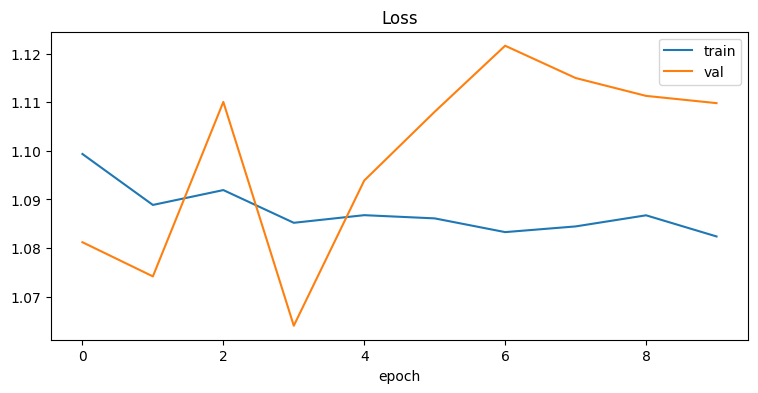

ValueError: Demasiado pocos trades OOS ejecutados: 0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Gráfica simple de loss
# =========================
if "history" in globals() and isinstance(history, dict) and "train_loss" in history and "val_loss" in history:
    plt.figure(figsize=(9, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

# =========================
# 1) Construir trades OOS ejecutados (ex) en rango df_test
# =========================
if "trades" not in globals():
    raise ValueError("No existe `trades` en memoria. Ejecuta antes el backtest que lo crea.")
if "df_test" not in globals():
    raise ValueError("No existe `df_test` en memoria.")

test_start = pd.to_datetime(df_test["datetime"], utc=True).min()
test_end   = pd.to_datetime(df_test["datetime"], utc=True).max()

ex = trades[
    (trades["datetime"] >= test_start) &
    (trades["datetime"] <= test_end) &
    (trades["signal"] != 0)
].copy().sort_values("datetime").reset_index(drop=True)

if len(ex) < 20:
    raise ValueError(f"Demasiado pocos trades OOS ejecutados: {len(ex)}")

# =========================
# 2) Métrica observada
# =========================
obs = ex["strat_logret"].astype(float).values
days = ex["datetime"].dt.floor("D").nunique()
tpd = len(ex) / max(days, 1)

obs_avg, obs_std = obs.mean(), obs.std(ddof=0)
obs_sharpe = (obs_avg / obs_std) * np.sqrt(252 * tpd) if obs_std > 0 else np.nan
obs_ret = np.exp(obs.sum()) - 1.0

print("OBS OOS (df_test)")
print(f"Executed trades: {len(ex)} | Days: {days} | Trades/day: {tpd:.2f}")
print(f"Total return: {obs_ret:.2%} | Sharpe(ann): {obs_sharpe:.2f}")

# columnas necesarias para los null tests
for c in ["fwd_logret_2h", "cost", "signal"]:
    if c not in ex.columns:
        raise ValueError(f"Falta la columna `{c}` en `ex`.")

fwd  = ex["fwd_logret_2h"].astype(float).values
cost = ex["cost"].astype(float).values
sig  = ex["signal"].astype(float).values

# =========================
# 3) PERM TEST (señal aleatoria)
# =========================
N = 5000
rng = np.random.default_rng(42)

sharpes_perm = np.empty(N, dtype=float)
rets_perm    = np.empty(N, dtype=float)

for i in range(N):
    sig_perm = rng.permutation(sig)  # rompe alineación señal-return
    strat = sig_perm * fwd - cost
    avg, std = strat.mean(), strat.std(ddof=0)
    sharpes_perm[i] = (avg / std) * np.sqrt(252 * tpd) if std > 0 else -np.inf
    rets_perm[i]    = np.exp(strat.sum()) - 1.0

p_sh_perm = (np.sum(sharpes_perm >= obs_sharpe) + 1) / (N + 1)
p_rt_perm = (np.sum(rets_perm    >= obs_ret)    + 1) / (N + 1)

print("\nPERM TEST (null = señal aleatoria)")
print(f"p-value Sharpe: {p_sh_perm:.4f} | null 95%: {np.quantile(sharpes_perm, 0.95):.2f}")
print(f"p-value Return: {p_rt_perm:.4f} | null 95%: {np.quantile(rets_perm, 0.95):.2%}")

plt.figure(figsize=(9, 4))
plt.hist(sharpes_perm[np.isfinite(sharpes_perm)], bins=60)
plt.axvline(obs_sharpe)
plt.title("PERM null: Sharpe")
plt.xlabel("Sharpe(ann)")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(rets_perm[np.isfinite(rets_perm)], bins=60)
plt.axvline(obs_ret)
plt.title("PERM null: Total return")
plt.xlabel("Total return")
plt.show()

# =========================
# 4) SHIFT TEST (circular shift: preserva estructura temporal de la señal)
# =========================
sharpes_shift = np.empty(N, dtype=float)
rets_shift    = np.empty(N, dtype=float)

for i in range(N):
    k = rng.integers(1, len(sig))  # shift no-cero
    sig_shift = np.roll(sig, k)
    strat = sig_shift * fwd - cost
    avg, std = strat.mean(), strat.std(ddof=0)
    sharpes_shift[i] = (avg / std) * np.sqrt(252 * tpd) if std > 0 else -np.inf
    rets_shift[i]    = np.exp(strat.sum()) - 1.0

p_sh_shift = (np.sum(sharpes_shift >= obs_sharpe) + 1) / (N + 1)
p_rt_shift = (np.sum(rets_shift    >= obs_ret)    + 1) / (N + 1)

print("\nSHIFT TEST (null = misma señal pero desalineada)")
print(f"p-value Sharpe: {p_sh_shift:.4f} | null 95%: {np.quantile(sharpes_shift, 0.95):.2f}")
print(f"p-value Return: {p_rt_shift:.4f} | null 95%: {np.quantile(rets_shift, 0.95):.2%}")

plt.figure(figsize=(9, 4))
plt.hist(sharpes_shift[np.isfinite(sharpes_shift)], bins=60)
plt.axvline(obs_sharpe)
plt.title("SHIFT null: Sharpe")
plt.xlabel("Sharpe(ann)")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(rets_shift[np.isfinite(rets_shift)], bins=60)
plt.axvline(obs_ret)
plt.title("SHIFT null: Total return")
plt.xlabel("Total return")
plt.show()
